# Fuel Inventory Management Project

Group project. We use Python to look at fuel purchases and tank inventory for a network of 8 gas stations in Hamilton, Ontario (January 2017 to August 2019), and answer four business questions:

1. How well is inventory managed today?
2. How should the stations order fuel to get bigger quantity discounts without running out?
3. Are prices different on different days of the week?
4. Is it worth replacing a tank with a bigger one?

All money is in Canadian dollars (CAD) and all volumes are in liters (L).

## Executive summary

**What we found**

* The stations order fuel in small amounts very often. 89% of all deliveries are below 15,000 L, which is the first discount level, so they get no discount at all. No delivery in the whole period reached the 40,000 L level. Total discounts earned over 956 days were CAD 205,979 (about 0.7 cents per liter).
* Station 1 (EastMount) is the only station that is really at risk of running out of fuel. Its gasoline inventory was below a 7-day reserve 53% of the time. The other stations keep 2 to 4 weeks of fuel and are not at risk, but they also don't get discounts.
* If every station orders when inventory reaches a 7-day reserve and orders the smallest amount that gets the best discount that fits in the tanks, discounts on the same amount of fuel go from CAD 205,979 to CAD 996,006. That is about CAD 300,000 more per year, with no investment. We replayed this rule day by day against real demand and it never ran out of fuel.
* Day of the week: box plots of the price per liter for Monday to Friday overlap almost completely, so there is not enough evidence that any day is cheaper. We don't recommend changing order days.
* Replacing a tank with a 60,000 L tank for CAD 250,000 does not pay back within 5 years at any station. The best cases (station 1 diesel and station 5 gasoline) would take 12 to 13 years to pay back.

**What we recommend**

1. Use the order trigger and order size in the summary table (section 6) at each station.
2. For station 1 diesel and stations 3, 4 and 5, decide whether to keep one extra day of safety stock, which costs one discount level.
3. Don't change order days because of price.
4. Don't replace tanks.

**Data problems to keep in mind:** all tanks stopped reporting between 1 May and 14 June 2018, station 3 is missing about 7 months of readings, and the invoice file seems to be missing some invoices (mostly diesel, and both fuels from spring 2019). Our savings numbers use the invoices, so they are on the conservative side.

## How to run this notebook

* **Google Colab:** upload the five CSV files when the first code cell asks for them, then *Runtime > Run all*. It takes about 2 minutes.
* **Jupyter:** put the notebook and the `data` folder in the same place and run all cells.
* We only use pandas, numpy and matplotlib. File paths are relative.

Assumptions from the project description that we use everywhere: orders arrive immediately, the full tank capacity can be used, delivery cost is ignored, discounts are per delivery for one station and one fuel type, and the invoice cost already includes the discount.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)

DATA_DIR = "data"
FILES = ["Locations.csv", "Tanks.csv", "Invoices.csv", "Fuel_Level_Part_1.csv", "Fuel_Level_Part_2.csv"]

def find_file(name):
    # look in the data folder first, then next to the notebook; also accept "-1" copies from the browser
    for path in [os.path.join(DATA_DIR, name), name,
                 os.path.join(DATA_DIR, name.replace(".csv", "-1.csv")), name.replace(".csv", "-1.csv")]:
        if os.path.exists(path):
            return path
    return None

missing = [f for f in FILES if find_file(f) is None]
if missing:
    try:
        from google.colab import files
        print("Please upload these files:", missing)
        uploaded = files.upload()
        os.makedirs(DATA_DIR, exist_ok=True)
        for name, content in uploaded.items():
            open(os.path.join(DATA_DIR, name), "wb").write(content)
    except ImportError:
        raise FileNotFoundError("Missing files: " + str(missing))

for f in FILES:
    print(f, "->", find_file(f))

Locations.csv -> data/Locations.csv
Tanks.csv -> data/Tanks.csv
Invoices.csv -> data/Invoices.csv
Fuel_Level_Part_1.csv -> data/Fuel_Level_Part_1.csv
Fuel_Level_Part_2.csv -> data/Fuel_Level_Part_2.csv


### Constants

The discount table and the other project assumptions are written once here.

In [2]:
def discount_rate(liters):
    # discount per liter for one delivery (from the project description)
    if liters >= 40000:
        return 0.04
    elif liters >= 25000:
        return 0.03
    elif liters >= 15000:
        return 0.02
    else:
        return 0.00

def discount_tier(liters):
    if liters >= 40000:
        return "40k+ (4c)"
    elif liters >= 25000:
        return "25k-40k (3c)"
    elif liters >= 15000:
        return "15k-25k (2c)"
    else:
        return "<15k (0c)"

RESERVE_DAYS = 7           # minimum reserve = 7 days of average consumption
NEW_TANK = 60000           # replacement tank size (L)
NEW_TANK_COST = 250000     # CAD per tank
YEARS = 5

# cleaning thresholds for the fuel level data (explained in section 1.4)
SPIKE = 2000       # a reading that is 2,000 L below both neighbours is a sensor error
GAP_HOURS = 6      # more than 6 hours between readings = data gap
DELIVERY = 500     # a rise of 500 L or more between readings = a delivery
MAX_DROP = 2000    # a drop of more than 2,000 L in 15 minutes cannot be sales
MIN_HOURS = 20     # a day needs 20 hours of readings to count as a complete day

## 1. Loading and cleaning the data

For each file we check missing values, duplicates, inconsistent IDs and impossible values, and write down what we did.

### 1.1 Locations

In [3]:
locations = pd.read_csv(find_file("Locations.csv"))
locations = locations.rename(columns={"Gas Station Location": "Station", "Gas Station Name": "Name"})
print(locations.isnull().sum())
locations

Station                  0
Name                     0
Gas Station Address      0
Gas Station Latitude     0
Gas Station Longitude    0
dtype: int64


,Station,Name,Gas Station Address,Gas Station Latitude,Gas Station Longitude
0,1,EastMount,"386 Upper Gage Ave, Hamilton, ON L8V 4H9, Canada",43.234670,-79.836510
1,2,Eastgate,"75 Centennial Pkwy N E5, Hamilton, ON L8E 2P2,...",43.230700,-79.763930
2,3,Central,"80 Park St N, Hamilton, ON L8R 2M9, Canada",43.260260,-79.870580
3,4,Chedoke,"16 McMaster Ave, Dundas, ON L9H 0A8, Canada",43.261849,-79.937057
4,5,Mountain View,"985 Scenic Dr, Hamilton, ON L9C 1H7, Canada",43.244910,-79.921850
5,6,Oakville,"503 Plains Rd E, Burlington, ON L7T 2E2, Canada",43.319160,-79.836340
6,7,Circle,"1170 Upper James St, Hamilton, ON L9C 3B1, Canada",43.216968,-79.894023
7,8,Chappel,"1530 Upper Sherman Ave, Hamilton, ON L8W 1C5, ...",38.875955,-77.024461


One problem: station 8 (Chappel) has an address in Hamilton but its latitude/longitude (38.88, -77.02) is in the Washington DC area. We don't use coordinates in any calculation, so we leave it and just note it.

### 1.2 Tanks

Tank IDs are written differently in different files (`T 12` and `T12`), so we remove the spaces everywhere. Regular (U) and premium (P) gasoline are both "G" on the invoices, so we add a column `Fuel` with G or D.

In [4]:
tanks = pd.read_csv(find_file("Tanks.csv"))
tanks = tanks.rename(columns={"Tank Location": "Station"})
tanks["Tank ID"] = tanks["Tank ID"].str.replace(" ", "")

def fuel_group(tank_type):
    if tank_type == "D":
        return "D"
    else:
        return "G"      # U and P are both gasoline

tanks["Fuel"] = tanks["Tank Type"].apply(fuel_group)
print("Duplicate tank IDs:", tanks["Tank ID"].duplicated().sum())
print("Tanks at unknown stations:", (~tanks["Station"].isin(locations["Station"])).sum())
tanks

Duplicate tank IDs: 0
Tanks at unknown stations: 0


,Tank ID,Station,Tank Number,Tank Type,Tank Capacity,Fuel
0,T10,1,1,U,40000,G
1,T11,1,2,U,40000,G
2,T12,1,3,D,40000,D
3,T13,1,4,P,40000,G
4,T14,1,5,U,40000,G
5,T15,1,6,D,40000,D
6,T16,2,1,U,70000,G
7,T17,2,2,D,40000,D
8,T18,2,3,U,40000,G
9,T19,2,4,D,70000,D


In [5]:
# total capacity for each station and fuel type
capacity = tanks.groupby(["Station", "Fuel"])["Tank Capacity"].sum().reset_index()
capacity = capacity.rename(columns={"Tank Capacity": "Capacity"})
capacity.pivot(index="Station", columns="Fuel", values="Capacity")

Fuel,D,G
Station,,
1,80000,160000
2,110000,110000
3,30000,30000
4,40000,40000
5,25000,25000
6,30000,60000
7,5000,5000
8,40000,40000


### 1.3 Invoices

What we found and what we did:

* 42 rows are completely empty (no cost, no amount, no fuel type). We drop them. The 5 rows with station numbers that don't exist (11, 17, 20, 21, 41) are all inside these empty rows, so we don't lose any real purchase.
* After that there are no duplicate rows and no duplicate invoice IDs.
* We add `Rate` = Gross Purchase Cost / Amount Purchased (CAD per liter), the discount tier of each delivery, the discount saved (= liters x discount per liter) and the price before discount (= Rate + discount per liter, as the description says).
* We check that no delivery is bigger than the station's total capacity for that fuel.

In [6]:
invoices = pd.read_csv(find_file("Invoices.csv"))
invoices = invoices.rename(columns={"Invoice Gas Station Location": "Station",
                                    "Gross Purchase Cost": "Cost", "Amount Purchased": "Liters"})
print("Rows before cleaning:", len(invoices))
print(invoices.isnull().sum())

empty = invoices["Cost"].isnull() & invoices["Liters"].isnull() & invoices["Fuel Type"].isnull()
bad_station = ~invoices["Station"].isin(locations["Station"])
print("Empty rows:", empty.sum(), "| rows with unknown station:", bad_station.sum(),
      "| unknown-station rows that are also empty:", (empty & bad_station).sum())

invoices = invoices[~empty].copy()
print("Duplicate rows:", invoices.duplicated().sum())
invoices = invoices.drop_duplicates()
print("Duplicate invoice IDs:", invoices["Invoice ID"].duplicated().sum())

invoices["Invoice ID"] = invoices["Invoice ID"].astype(int)
invoices["Date"] = pd.to_datetime(invoices["Invoice Date"], format="%m/%d/%Y")
invoices["Weekday"] = invoices["Date"].dt.day_name()
invoices["Rate"] = invoices["Cost"] / invoices["Liters"]
invoices["Discount"] = invoices["Liters"].apply(discount_rate)
invoices["Tier"] = invoices["Liters"].apply(discount_tier)
invoices["Saved"] = invoices["Liters"] * invoices["Discount"]
invoices["Rate_before_discount"] = invoices["Rate"] + invoices["Discount"]

# plausibility: delivery bigger than the station's capacity?
invoices = invoices.merge(capacity, left_on=["Station", "Fuel Type"], right_on=["Station", "Fuel"], how="left")
print("Deliveries bigger than station capacity:", (invoices["Liters"] > invoices["Capacity"]).sum())
invoices = invoices.drop(columns=["Fuel", "Capacity"])

START, END = invoices["Date"].min(), invoices["Date"].max()
DAYS = (END - START).days + 1
print("Rows after cleaning:", len(invoices), "| period:", START.date(), "to", END.date(), "=", DAYS, "days")
invoices.head()

Rows before cleaning: 2873
Invoice Date     0
Invoice ID      41
Station          0
Cost            42
Liters          42
Fuel Type       42
dtype: int64
Empty rows: 42 | rows with unknown station: 5 | unknown-station rows that are also empty: 5
Duplicate rows: 0
Duplicate invoice IDs: 0
Deliveries bigger than station capacity: 0
Rows after cleaning: 2831 | period: 2017-01-02 to 2019-08-15 = 956 days


,Invoice Date,Invoice ID,Station,Cost,Liters,Fuel Type,Date,Weekday,Rate,Discount,Tier,Saved,Rate_before_discount
0,1/2/2017,10000,1,7570.82000,6609.600,G,2017-01-02,Monday,1.145428,0.0,<15k (0c),0.0,1.145428
1,1/2/2017,10001,1,12491.85300,9338.736,D,2017-01-02,Monday,1.337639,0.0,<15k (0c),0.0,1.337639
2,1/2/2017,10002,2,17034.34500,13377.824,D,2017-01-02,Monday,1.273327,0.0,<15k (0c),0.0,1.273327
3,1/2/2017,10003,2,12616.77153,9432.112,D,2017-01-02,Monday,1.337640,0.0,<15k (0c),0.0,1.337640
4,1/2/2017,10004,4,11363.80082,9139.200,D,2017-01-02,Monday,1.243413,0.0,<15k (0c),0.0,1.243413


In [7]:
invoices[["Liters", "Cost", "Rate"]].describe().round(3)

,Liters,Cost,Rate
count,2831.000,2831.000,2831.000
mean,10270.822,11762.178,1.210
std,6101.906,6562.633,0.335
min,96.976,94.635,0.877
25%,7073.384,8327.902,1.021
50%,9262.304,10459.088,1.062
75%,11435.984,12518.351,1.221
max,33826.560,33118.552,3.239


### 1.4 Fuel levels

The two files have different column names (`Fuel Level` vs `Fuel_Level`, `Time stamp` vs `Timestamp`), so we rename them to be the same and then stack them. Then we clean the tank IDs, convert the timestamps and check for problems.

In [8]:
levels1 = pd.read_csv(find_file("Fuel_Level_Part_1.csv"))
levels2 = pd.read_csv(find_file("Fuel_Level_Part_2.csv"))
print(levels1.columns.tolist(), levels2.columns.tolist())
levels1.columns = ["Tank ID", "Level", "Time"]
levels2.columns = ["Tank ID", "Level", "Time"]
levels = pd.concat([levels1, levels2], ignore_index=True)
print("Rows:", len(levels))

levels["Tank ID"] = levels["Tank ID"].str.replace(" ", "")
levels["Time"] = pd.to_datetime(levels["Time"], format="%m/%d/%Y %H:%M")

print("Missing values:", levels.isnull().sum().sum())
levels = levels.dropna()
print("Exact duplicate rows:", levels.duplicated().sum())
levels = levels.drop_duplicates()
print("Same tank and time but different level:", levels.duplicated(subset=["Tank ID", "Time"]).sum(), "(we keep the last one)")
levels = levels.drop_duplicates(subset=["Tank ID", "Time"], keep="last")
print("Unknown tank IDs:", (~levels["Tank ID"].isin(tanks["Tank ID"])).sum())

levels = levels.merge(tanks[["Tank ID", "Station", "Fuel", "Tank Capacity"]], on="Tank ID")
print("Negative levels:", (levels["Level"] < 0).sum(), "| levels above capacity:", (levels["Level"] > levels["Tank Capacity"]).sum())
levels = levels.sort_values(["Tank ID", "Time"]).reset_index(drop=True)
print("Clean rows:", len(levels), "| from", levels["Time"].min(), "to", levels["Time"].max())

['Tank ID', 'Fuel Level', 'Time stamp'] ['Tank ID', 'Fuel_Level', 'Timestamp']
Rows: 1859660


Missing values: 2


Exact duplicate rows: 71


Same tank and time but different level: 48 (we keep the last one)


Unknown tank IDs: 0
Negative levels: 0 | levels above capacity: 0


Clean rows: 1859539 | from 2017-01-01 00:05:00 to 2019-08-15 23:59:00


In [9]:
levels.groupby("Tank ID").agg(first=("Time", "min"), last=("Time", "max"), readings=("Level", "count"),
                              min_level=("Level", "min"), max_level=("Level", "max"), capacity=("Tank Capacity", "first"))

,first,last,readings,min_level,max_level,capacity
Tank ID,,,,,,
T10,2017-01-01 00:09:00,2019-08-07 18:13:00,83909,4483.0,36530.0,40000
T11,2017-01-01 00:10:00,2019-08-07 18:13:00,83834,7458.0,37824.0,40000
T12,2017-01-01 00:10:00,2019-08-07 18:13:00,83778,2567.0,36068.0,40000
T13,2017-01-01 00:10:00,2019-08-07 18:13:00,83741,5001.0,36299.0,40000
T14,2017-01-01 00:10:00,2019-08-07 18:14:00,83511,9048.0,37404.0,40000
T15,2017-01-01 00:10:00,2019-08-07 18:14:00,83691,6814.0,37340.0,40000
T16,2017-01-01 00:12:00,2019-08-15 23:57:00,87254,47496.0,68483.0,70000
T17,2017-01-01 00:12:00,2019-08-15 23:57:00,87256,11822.0,38086.0,40000
T18,2017-01-01 00:13:00,2019-08-15 23:57:00,87249,12091.0,36613.0,40000


**Reading intervals and gaps.** Readings are normally 15 minutes apart. But there are long gaps: all tanks stopped reporting from 1 May to 14 June 2018 (44 days), station 3 has gaps of 5 months and 2 months, tank T31 is missing August to October 2017, and station 7 only starts in June 2017. We treat any interval longer than 6 hours as a gap and don't calculate anything across it.

In [10]:
levels["hours"] = levels.groupby("Tank ID")["Time"].diff().dt.total_seconds() / 3600
print(levels["hours"].describe().round(2))
gaps = levels[levels["hours"] > GAP_HOURS].copy()
gaps["days"] = (gaps["hours"] / 24).round(1)
print("\nNumber of gaps longer than 6 hours:", len(gaps))
gaps.sort_values("days", ascending=False)[["Tank ID", "Station", "Time", "days"]].head(10)

count    1859516.00
mean           0.28
std            5.88
min            0.02
25%            0.25
50%            0.25
75%            0.25
max         3851.37
Name: hours, dtype: float64

Number of gaps longer than 6 hours: 165


,Tank ID,Station,Time,days
875715,T20,3,2018-02-19 13:45:00,160.5
943765,T21,3,2018-02-19 13:45:00,160.5
1718119,T31,8,2017-10-20 08:02:00,71.5
882443,T20,3,2018-07-04 10:16:00,64.0
950493,T21,3,2018-07-04 10:16:00,64.0
548855,T16,2,2018-06-14 10:25:00,44.0
1262558,T25,5,2018-06-14 10:30:00,44.0
1116066,T23,4,2018-06-14 10:28:00,44.0
1190250,T24,5,2018-06-14 10:30:00,44.0
1032385,T22,4,2018-06-14 10:28:00,44.0


**Sensor spikes.** Some readings drop by thousands of liters and come straight back 15 minutes later (for example T11 on 30 October 2018 jumps between 25,000 L and 17,000 L four times in one hour). Fuel can't be sold and refilled that fast, so these are sensor errors. We remove a reading if it is more than 2,000 L below both the reading before and the reading after it.

pass 1 - spikes removed: 15


pass 2 - spikes removed: 0


pass 3 - spikes removed: 0


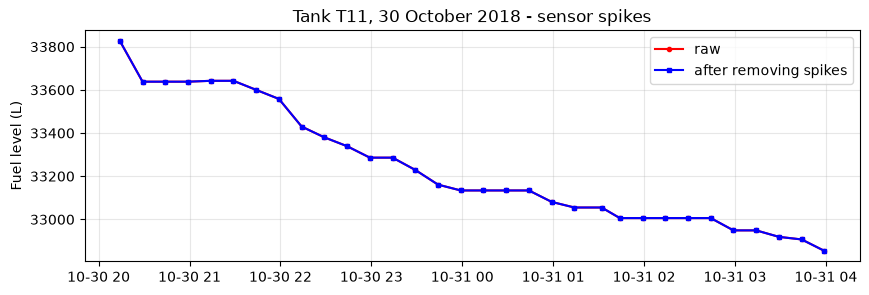

In [11]:
before = levels[(levels["Tank ID"] == "T11") & (levels["Time"] >= "2018-10-30 20:00") & (levels["Time"] <= "2018-10-31 04:00")]

for i in range(3):   # repeat a few times in case spikes are next to each other
    prev_level = levels.groupby("Tank ID")["Level"].shift(1)
    next_level = levels.groupby("Tank ID")["Level"].shift(-1)
    spike = (prev_level - levels["Level"] > SPIKE) & (next_level - levels["Level"] > SPIKE)
    print("pass", i + 1, "- spikes removed:", spike.sum())
    levels = levels[~spike].reset_index(drop=True)

after = levels[(levels["Tank ID"] == "T11") & (levels["Time"] >= "2018-10-30 20:00") & (levels["Time"] <= "2018-10-31 04:00")]
plt.figure(figsize=(10, 3))
plt.plot(before["Time"], before["Level"], "o-", markersize=3, color="red", label="raw")
plt.plot(after["Time"], after["Level"], "s-", markersize=3, color="blue", label="after removing spikes")
plt.title("Tank T11, 30 October 2018 - sensor spikes")
plt.ylabel("Fuel level (L)"); plt.legend(); plt.grid(alpha=0.3); plt.show()

**Classifying each change between two readings.** After removing spikes, we look at the change from one reading to the next for each tank:

| Type | Rule | Meaning |
|---|---|---|
| normal | small change, less than 6 hours apart | the drop is fuel sold |
| delivery | level goes up by 500 L or more | a truck delivered fuel |
| anomaly | level drops by more than 2,000 L in one interval and doesn't come back | not sales (maybe a transfer or a gauge reset); we ignore it |
| gap | more than 6 hours since the last reading | we don't know what happened |

Daily consumption of a tank = sum of the "normal" drops that day. A day is **complete** if it has at least 20 hours of readings and no anomaly. For a station and fuel type we add up the tanks, and we only use days where all the tanks are complete.

In [12]:
levels["hours"] = levels.groupby("Tank ID")["Time"].diff().dt.total_seconds() / 3600
levels["change"] = levels.groupby("Tank ID")["Level"].diff()

levels["type"] = "normal"
levels.loc[levels["change"].isnull(), "type"] = "first"
levels.loc[levels["hours"] > GAP_HOURS, "type"] = "gap"
levels.loc[(levels["type"] == "normal") & (levels["change"] >= DELIVERY), "type"] = "delivery"
levels.loc[(levels["type"] == "normal") & (levels["change"] < -MAX_DROP * np.maximum(levels["hours"], 1)), "type"] = "anomaly"
print(levels["type"].value_counts())

levels["sold"] = np.where(levels["type"] == "normal", -levels["change"], 0)
levels["delivered"] = np.where(levels["type"] == "delivery", levels["change"], 0)
levels["hours_ok"] = np.where(levels["type"].isin(["normal", "delivery"]), levels["hours"], 0)
levels["is_anomaly"] = (levels["type"] == "anomaly").astype(int)
levels["Date"] = levels["Time"].dt.normalize()

print("\nAnomalies (ignored):")
levels[levels["type"] == "anomaly"][["Tank ID", "Station", "Time", "Level", "change", "hours"]]

type
normal      1853802
delivery       5523
gap             165
first            23
anomaly          11
Name: count, dtype: int64

Anomalies (ignored):


,Tank ID,Station,Time,Level,change,hours
19211,T10,1,2017-07-21 05:59:00,7969.0,-11042.0,0.750000
144224,T11,1,2018-11-07 09:44:00,31370.0,-6454.0,0.250000
227329,T12,1,2018-10-31 00:14:00,23709.0,-6223.0,0.250000
230514,T12,1,2018-12-03 09:29:00,23058.0,-10981.0,0.500000
230515,T12,1,2018-12-03 09:44:00,18689.0,-4369.0,0.250000
299925,T13,1,2018-07-06 05:28:00,7810.0,-17576.0,0.250000
394846,T14,1,2018-10-31 00:14:00,27055.0,-4342.0,0.250000
437972,T15,1,2017-07-21 06:15:00,25904.0,-4872.0,1.016667
467169,T15,1,2018-07-06 05:13:00,23906.0,-3100.0,0.250000
481548,T15,1,2018-12-03 10:44:00,9407.0,-19102.0,0.250000


In [13]:
# daily numbers per tank
daily_tank = levels.groupby(["Tank ID", "Station", "Fuel", "Date"]).agg(
    sold=("sold", "sum"), delivered=("delivered", "sum"), hours_ok=("hours_ok", "sum"), anomalies=("is_anomaly", "sum")).reset_index()
daily_tank["complete"] = (daily_tank["hours_ok"] >= MIN_HOURS) & (daily_tank["anomalies"] == 0)

# daily numbers per station and fuel type
daily = daily_tank.groupby(["Station", "Fuel", "Date"]).agg(
    sold=("sold", "sum"), delivered=("delivered", "sum"), tanks_complete=("complete", "sum"), tanks=("Tank ID", "count")).reset_index()
n_tanks = tanks.groupby(["Station", "Fuel"])["Tank ID"].count().rename("n_tanks").reset_index()
daily = daily.merge(n_tanks, on=["Station", "Fuel"])
daily["complete"] = daily["tanks_complete"] == daily["n_tanks"]
print("Share of station-fuel days that are complete:", round(daily["complete"].mean() * 100, 1), "%")
daily.groupby(["Station", "Fuel"])["complete"].agg(["sum", "count"]).rename(columns={"sum": "complete days", "count": "days with data"}).T

Share of station-fuel days that are complete: 98.5 %


Station           1         2         3         4         5         6         7         8     
Fuel              D    G    D    G    D    G    D    G    D    G    D    G    D    G    D    G
complete days   862  859  907  907  704  704  868  869  905  905  893  893  724  724  823  857
days with data  882  882  914  914  718  718  881  881  913  913  901  901  737  737  839  872

### 1.5 Summary of cleaning decisions

| Data | Problem | Rows | What we did |
|---|---|---|---|
| Locations | Station 8 coordinates don't match the address | 1 | Kept, not used in calculations |
| Invoices | Empty rows (including the 5 unknown station numbers) | 42 | Dropped |
| Invoices | Delivery bigger than station capacity | 0 | none found |
| Fuel levels | Missing values | 2 | Dropped |
| Fuel levels | Exact duplicates | 71 | Dropped |
| Fuel levels | Same tank and time, different level | 48 | Kept the last one |
| Fuel levels | Negative or above capacity | 0 | none found |
| Fuel levels | Sensor spikes | 15 | Dropped |
| Fuel levels | Large unexplained drops | 11 | Ignored in consumption, day not used in averages |
| Fuel levels | Gaps longer than 6 hours | 165 | No consumption calculated across the gap |

## 2. Question 1: How is inventory managed today?

### 2.1 Fuel level of every tank over time

One panel per tank (daily average level). The dashed line is the tank capacity. Each "tooth" is one delivery followed by sales. Flat parts are periods with no readings.

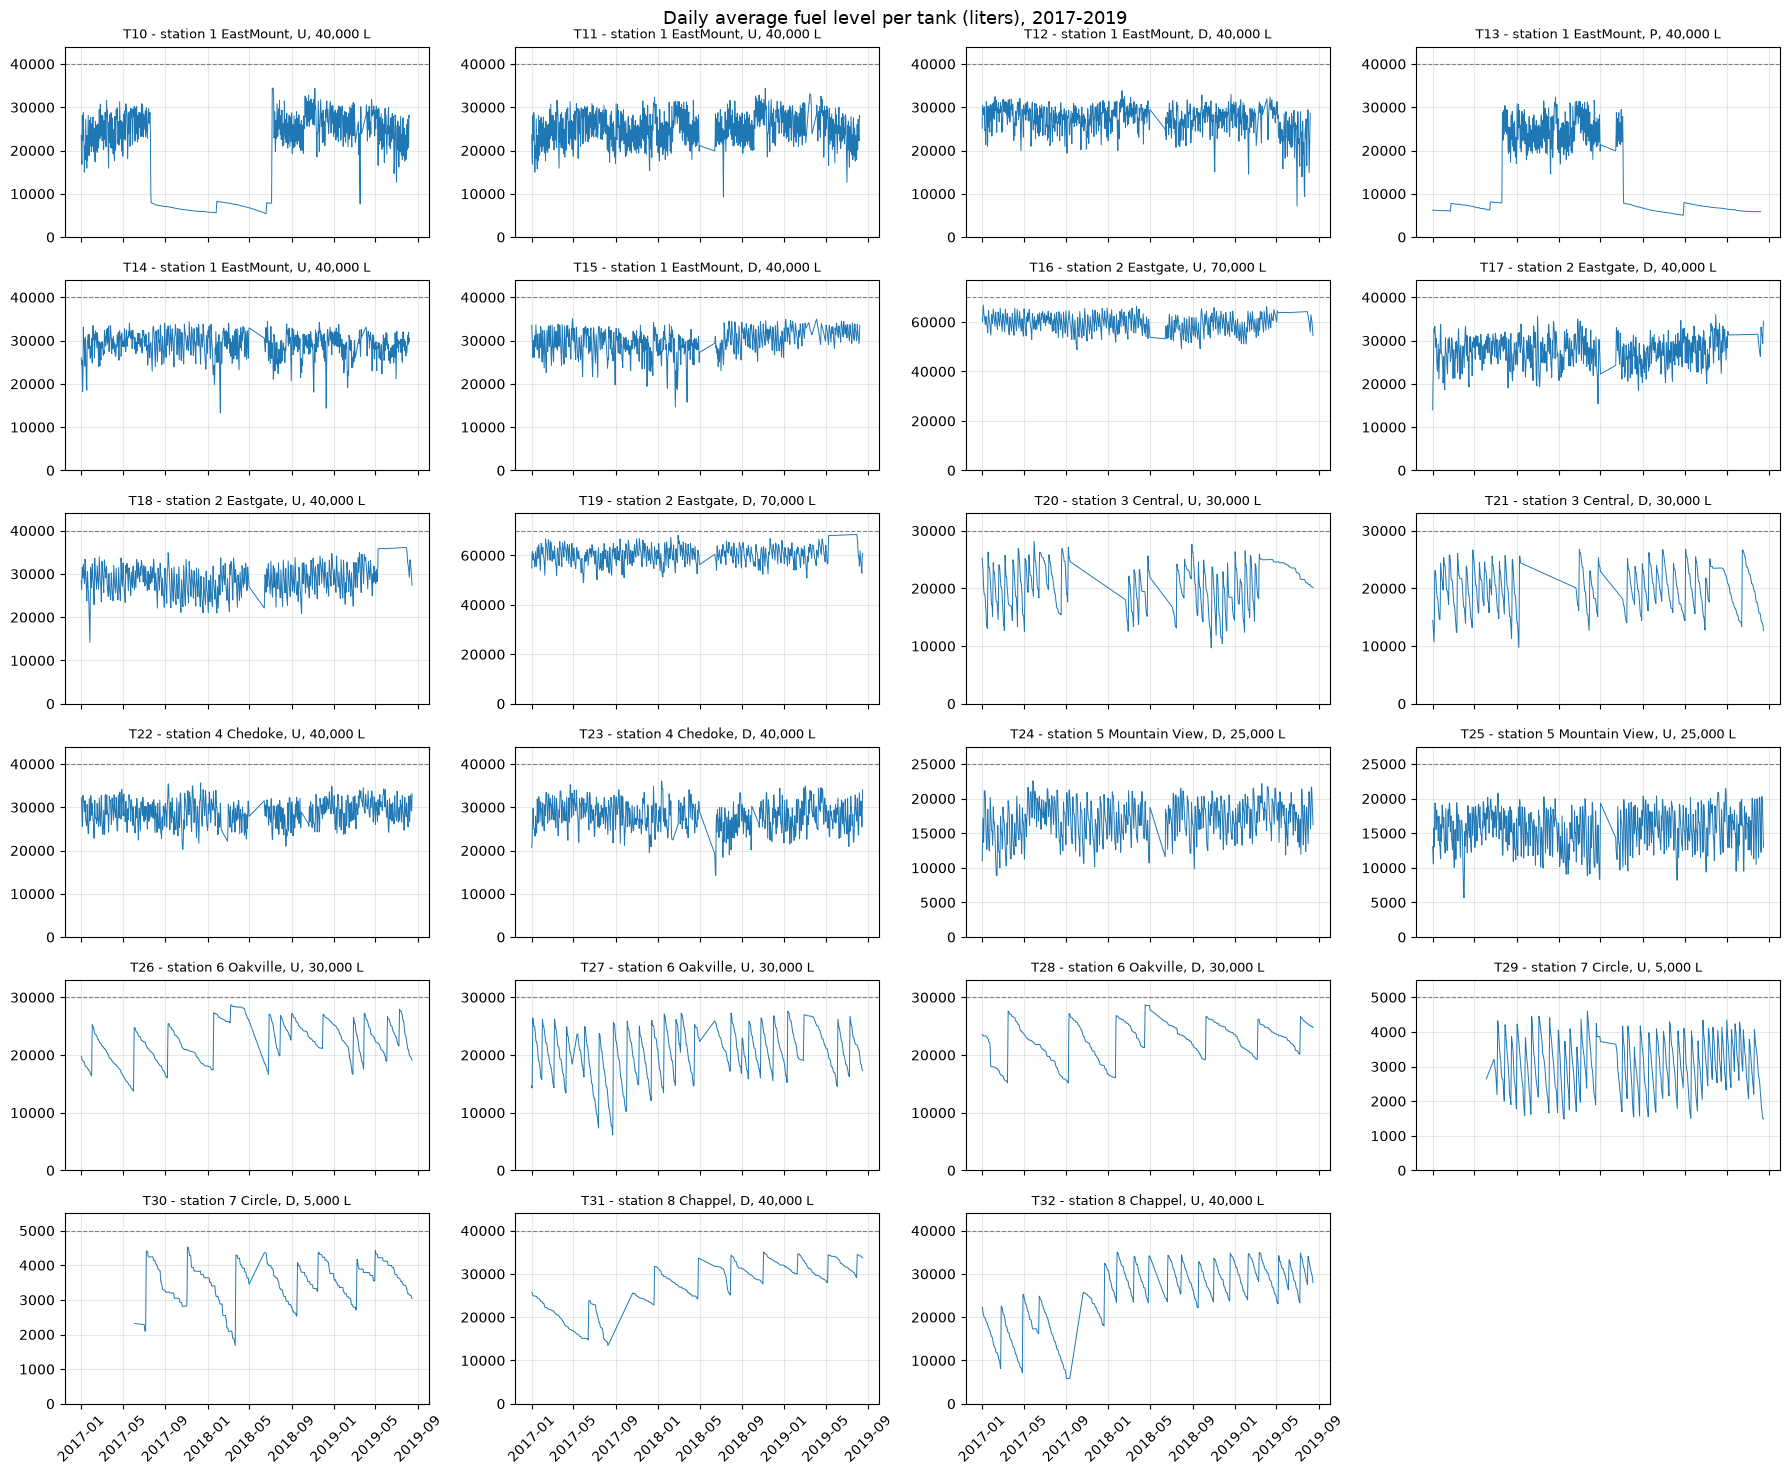

In [14]:
daily_level_tank = levels.groupby(["Tank ID", "Date"])["Level"].mean().reset_index()
tank_list = tanks.sort_values(["Station", "Tank Number"])["Tank ID"].tolist()
names = locations.set_index("Station")["Name"]

fig, axes = plt.subplots(6, 4, figsize=(18, 15), sharex=True)
axes = axes.flatten()
for i, tank_id in enumerate(tank_list):
    d = daily_level_tank[daily_level_tank["Tank ID"] == tank_id]
    t = tanks[tanks["Tank ID"] == tank_id].iloc[0]
    axes[i].plot(d["Date"], d["Level"], linewidth=0.7)
    axes[i].axhline(t["Tank Capacity"], linestyle="--", color="grey", linewidth=0.8)
    axes[i].set_title(f"{tank_id} - station {t['Station']} {names[t['Station']]}, {t['Tank Type']}, {t['Tank Capacity']:,} L", fontsize=9)
    axes[i].set_ylim(0, t["Tank Capacity"] * 1.1)
    axes[i].grid(alpha=0.3)
axes[-1].axis("off")
for ax in axes[19:23]:
    ax.tick_params(axis="x", rotation=45)
fig.suptitle("Daily average fuel level per tank (liters), 2017-2019", fontsize=13)
plt.tight_layout(); plt.show()

Zooming in on two weeks at station 1 shows the individual deliveries (red dots).

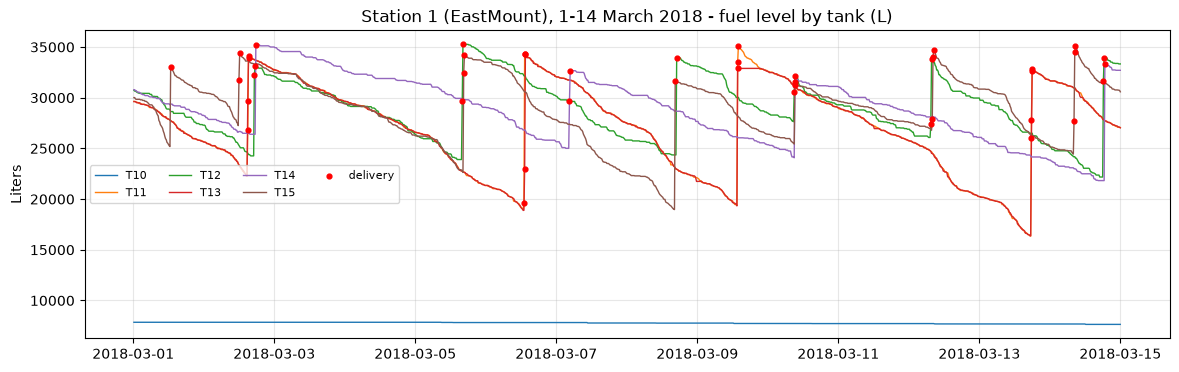

In [15]:
zoom = levels[(levels["Station"] == 1) & (levels["Time"] >= "2018-03-01") & (levels["Time"] < "2018-03-15")]
plt.figure(figsize=(14, 4))
for tank_id in zoom["Tank ID"].unique():
    d = zoom[zoom["Tank ID"] == tank_id]
    plt.plot(d["Time"], d["Level"], linewidth=1, label=tank_id)
deliveries = zoom[zoom["type"] == "delivery"]
plt.scatter(deliveries["Time"], deliveries["Level"], color="red", s=12, zorder=5, label="delivery")
plt.title("Station 1 (EastMount), 1-14 March 2018 - fuel level by tank (L)")
plt.ylabel("Liters"); plt.legend(ncol=4, fontsize=8); plt.grid(alpha=0.3); plt.show()

### 2.2 Daily consumption by station and fuel type

We take the average of the complete days. To check the method, we compare three numbers that should be close: fuel delivered according to the gauges, fuel sold according to the gauges, and fuel bought according to the invoices.

In [16]:
consumption = daily[daily["complete"]].groupby(["Station", "Fuel"])["sold"].agg(
    avg_daily="mean", std_daily="std", p95_daily=lambda x: x.quantile(0.95), max_daily="max", complete_days="count").round(0)
consumption

avg_daily  std_daily  p95_daily  max_daily  complete_days
Station Fuel                                                           
1       D        7080.0     2172.0    10990.0    15032.0            862
        G       12480.0     2827.0    16641.0    23397.0            859
2       D        4098.0     2594.0     7579.0    10077.0            907
        G        3146.0     1570.0     5103.0     7457.0            907
3       D         450.0      429.0     1194.0     2017.0            704
        G         512.0      633.0     1734.0     2911.0            704
4       D        2087.0     1676.0     4833.0     7446.0            868
        G        1897.0     1356.0     3505.0     4951.0            869
5       D        1043.0      830.0     2296.0     3921.0            905
        G        1538.0     1106.0     2940.0     3864.0            905
6       D          67.0      145.0      297.0     2006.0            893
        G         434.0      360.0      997.0     1514.0            893
7       D          16.0       41.0      108.0      316.0            724
        G         124.0       87.0      271.0      495.0            724
8       D          74.0      132.0      348.0      897.0            823
        G         243.0      219.0      599.0     1026.0            857

In [17]:
check = daily.groupby(["Station", "Fuel"]).agg(gauge_sold=("sold", "sum"), gauge_delivered=("delivered", "sum"))
invoiced = invoices.groupby(["Station", "Fuel Type"])["Liters"].sum()
invoiced.index.names = ["Station", "Fuel"]
check["invoiced"] = invoiced
check["delivered vs invoiced"] = ((check["gauge_delivered"] / check["invoiced"] - 1) * 100).round(1)
check["sold vs invoiced"] = ((check["gauge_sold"] / check["invoiced"] - 1) * 100).round(1)
check.round(0)

gauge_sold  gauge_delivered    invoiced  delivered vs invoiced  sold vs invoiced
Station Fuel                                                                                  
1       D      6186796.0        6206862.0   4872458.0                   27.0              27.0
        G     10923345.0       10958716.0  10866211.0                    1.0               0.0
2       D      3728729.0        3750115.0   3460900.0                    8.0               8.0
        G      2866365.0        2863714.0   2822514.0                    2.0               2.0
3       D       321422.0         335496.0    431815.0                  -22.0             -26.0
        G       368224.0         385902.0    423519.0                   -9.0             -13.0
4       D      1828240.0        1851656.0   1632468.0                   13.0              12.0
        G      1659770.0        1655830.0   1578618.0                    5.0               5.0
5       D       945913.0         967696.0    811734.0                   19.0              16.0
        G      1396876.0        1396678.0   1346713.0                    4.0               4.0
6       D        60389.0          64806.0     54630.0                   19.0              10.0
        G       389701.0         390097.0    386680.0                    1.0               1.0
7       D        11925.0          11771.0     11082.0                    6.0               8.0
        G        90569.0          89045.0     93563.0                   -5.0              -3.0
8       D        63310.0          62172.0     76051.0                  -18.0             -17.0
        G       210720.0         206185.0    207743.0                   -1.0               1.0

For gasoline the three numbers agree within a few percent, so the method works. For diesel the gauges show 8 to 27% more fuel than the invoices at stations 1, 2, 4, 5 and 6. Because the two gauge numbers agree with each other, we think the invoice file is missing some diesel invoices (the description says invoice details were changed). The quarterly check below shows the gap is biggest in 2019, for both fuels. Station 3 and station 8 diesel show the opposite because of their long reading gaps.

This matters for our results: consumption and reserves come from the gauges (complete), but discount savings are calculated on invoiced liters, so the savings we report are on the low side.

**Limits of the method:** sales during the 15 minutes when a truck is unloading are not seen, sales during gaps are not seen (those days are left out), gauge noise adds a bit of variance, and the 11 unexplained drops are ignored rather than explained.

In [18]:
quarterly = daily.groupby(["Fuel", pd.Grouper(key="Date", freq="QS")])["delivered"].sum().rename("gauge").reset_index()
inv_q = invoices.groupby(["Fuel Type", pd.Grouper(key="Date", freq="QS")])["Liters"].sum().rename("invoiced").reset_index()
inv_q = inv_q.rename(columns={"Fuel Type": "Fuel"})
quarterly = quarterly.merge(inv_q, on=["Fuel", "Date"])
quarterly["gauge / invoiced"] = (quarterly["gauge"] / quarterly["invoiced"]).round(2)
quarterly["Quarter"] = quarterly["Date"].dt.to_period("Q").astype(str)
quarterly.pivot(index="Fuel", columns="Quarter", values="gauge / invoiced")

Quarter,2017Q1,2017Q2,2017Q3,2017Q4,2018Q1,2018Q2,2018Q3,2018Q4,2019Q1,2019Q2,2019Q3
Fuel,,,,,,,,,,,
D,1.34,1.23,1.19,1.18,1.14,0.62,1.07,1.02,1.26,2.25,1.68
G,1.21,1.02,0.89,0.92,0.93,0.51,1.02,1.06,1.16,1.65,1.57


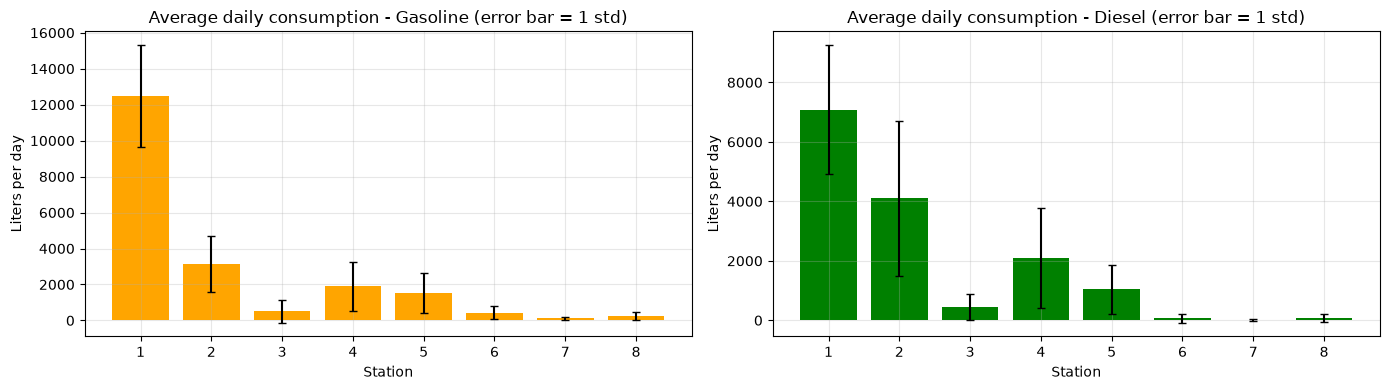

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, fuel, color in [(axes[0], "G", "orange"), (axes[1], "D", "green")]:
    d = consumption.xs(fuel, level="Fuel")
    ax.bar(d.index.astype(str), d["avg_daily"], yerr=d["std_daily"], capsize=3, color=color)
    ax.set_title("Average daily consumption - " + ("Gasoline" if fuel == "G" else "Diesel") + " (error bar = 1 std)")
    ax.set_xlabel("Station"); ax.set_ylabel("Liters per day"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2.3 How low does inventory get?

For each station and fuel type we add up the daily average level of its tanks, and compare it to the 7-day reserve (7 x average daily consumption) and to the capacity.

In [20]:
daily_level = levels.groupby(["Station", "Fuel", "Date"]).agg(level=("Level", "mean"), tanks=("Tank ID", "nunique")).reset_index()
# "mean" above is the mean per reading; multiply by number of tanks to get the station total
daily_level["level"] = daily_level["level"] * daily_level["tanks"]
daily_level = daily_level.merge(n_tanks, on=["Station", "Fuel"])
daily_level = daily_level[daily_level["tanks"] == daily_level["n_tanks"]]   # only days where every tank has readings

position = capacity.set_index(["Station", "Fuel"]).copy()
position["avg_daily"] = consumption["avg_daily"]
position["reserve_7d"] = (RESERVE_DAYS * position["avg_daily"]).round(0)
rows = []
for (station, fuel), r in position.iterrows():
    d = daily_level[(daily_level["Station"] == station) & (daily_level["Fuel"] == fuel)]
    rows.append({"Station": station, "Fuel": fuel,
                 "days below reserve %": round((d["level"] < r["reserve_7d"]).mean() * 100, 1),
                 "days below 10% capacity %": round((d["level"] < 0.1 * r["Capacity"]).mean() * 100, 1),
                 "min level": round(d["level"].min()),
                 "min level in days": round(d["level"].min() / r["avg_daily"], 1),
                 "avg level in days": round(d["level"].mean() / r["avg_daily"], 1)})
position = position.join(pd.DataFrame(rows).set_index(["Station", "Fuel"]))
position

Capacity  avg_daily  reserve_7d  days below reserve %  days below 10% capacity %  min level  min level in days  avg level in days
Station Fuel                                                                                                                                   
1       D        80000     7080.0     49560.0                   6.2                        0.0      38989                5.5                8.0
        G       160000    12480.0     87360.0                  56.5                        0.0      56415                4.5                6.9
2       D       110000     4098.0     28686.0                   0.0                        0.0      67935               16.6               21.7
        G       110000     3146.0     22022.0                   0.0                        0.0      68860               21.9               28.3
3       D        30000      450.0      3150.0                   0.0                        0.0       9761               21.7               44.2
        G        30000      512.0      3584.0                   0.0                        0.0       9674               18.9               40.4
4       D        40000     2087.0     14609.0                   0.2                        0.0      14260                6.8               13.4
        G        40000     1897.0     13279.0                   0.0                        0.0      20290               10.7               15.2
5       D        25000     1043.0      7301.0                   0.0                        0.0       8885                8.5               16.3
        G        25000     1538.0     10766.0                   5.0                        0.0       5685                3.7               10.1
6       D        30000       67.0       469.0                   0.0                        0.0      15130              225.8              335.5
        G        60000      434.0      3038.0                   0.0                        0.0      23770               54.8               98.9
7       D         5000       16.0       112.0                   0.0                        0.0       1684              105.3              219.6
        G         5000      124.0       868.0                   0.0                        0.0       1484               12.0               24.5
8       D        40000       74.0       518.0                   0.0                        0.0      13405              181.1              368.0
        G        40000      243.0      1701.0                   0.0                        0.0       5815               23.9              102.5

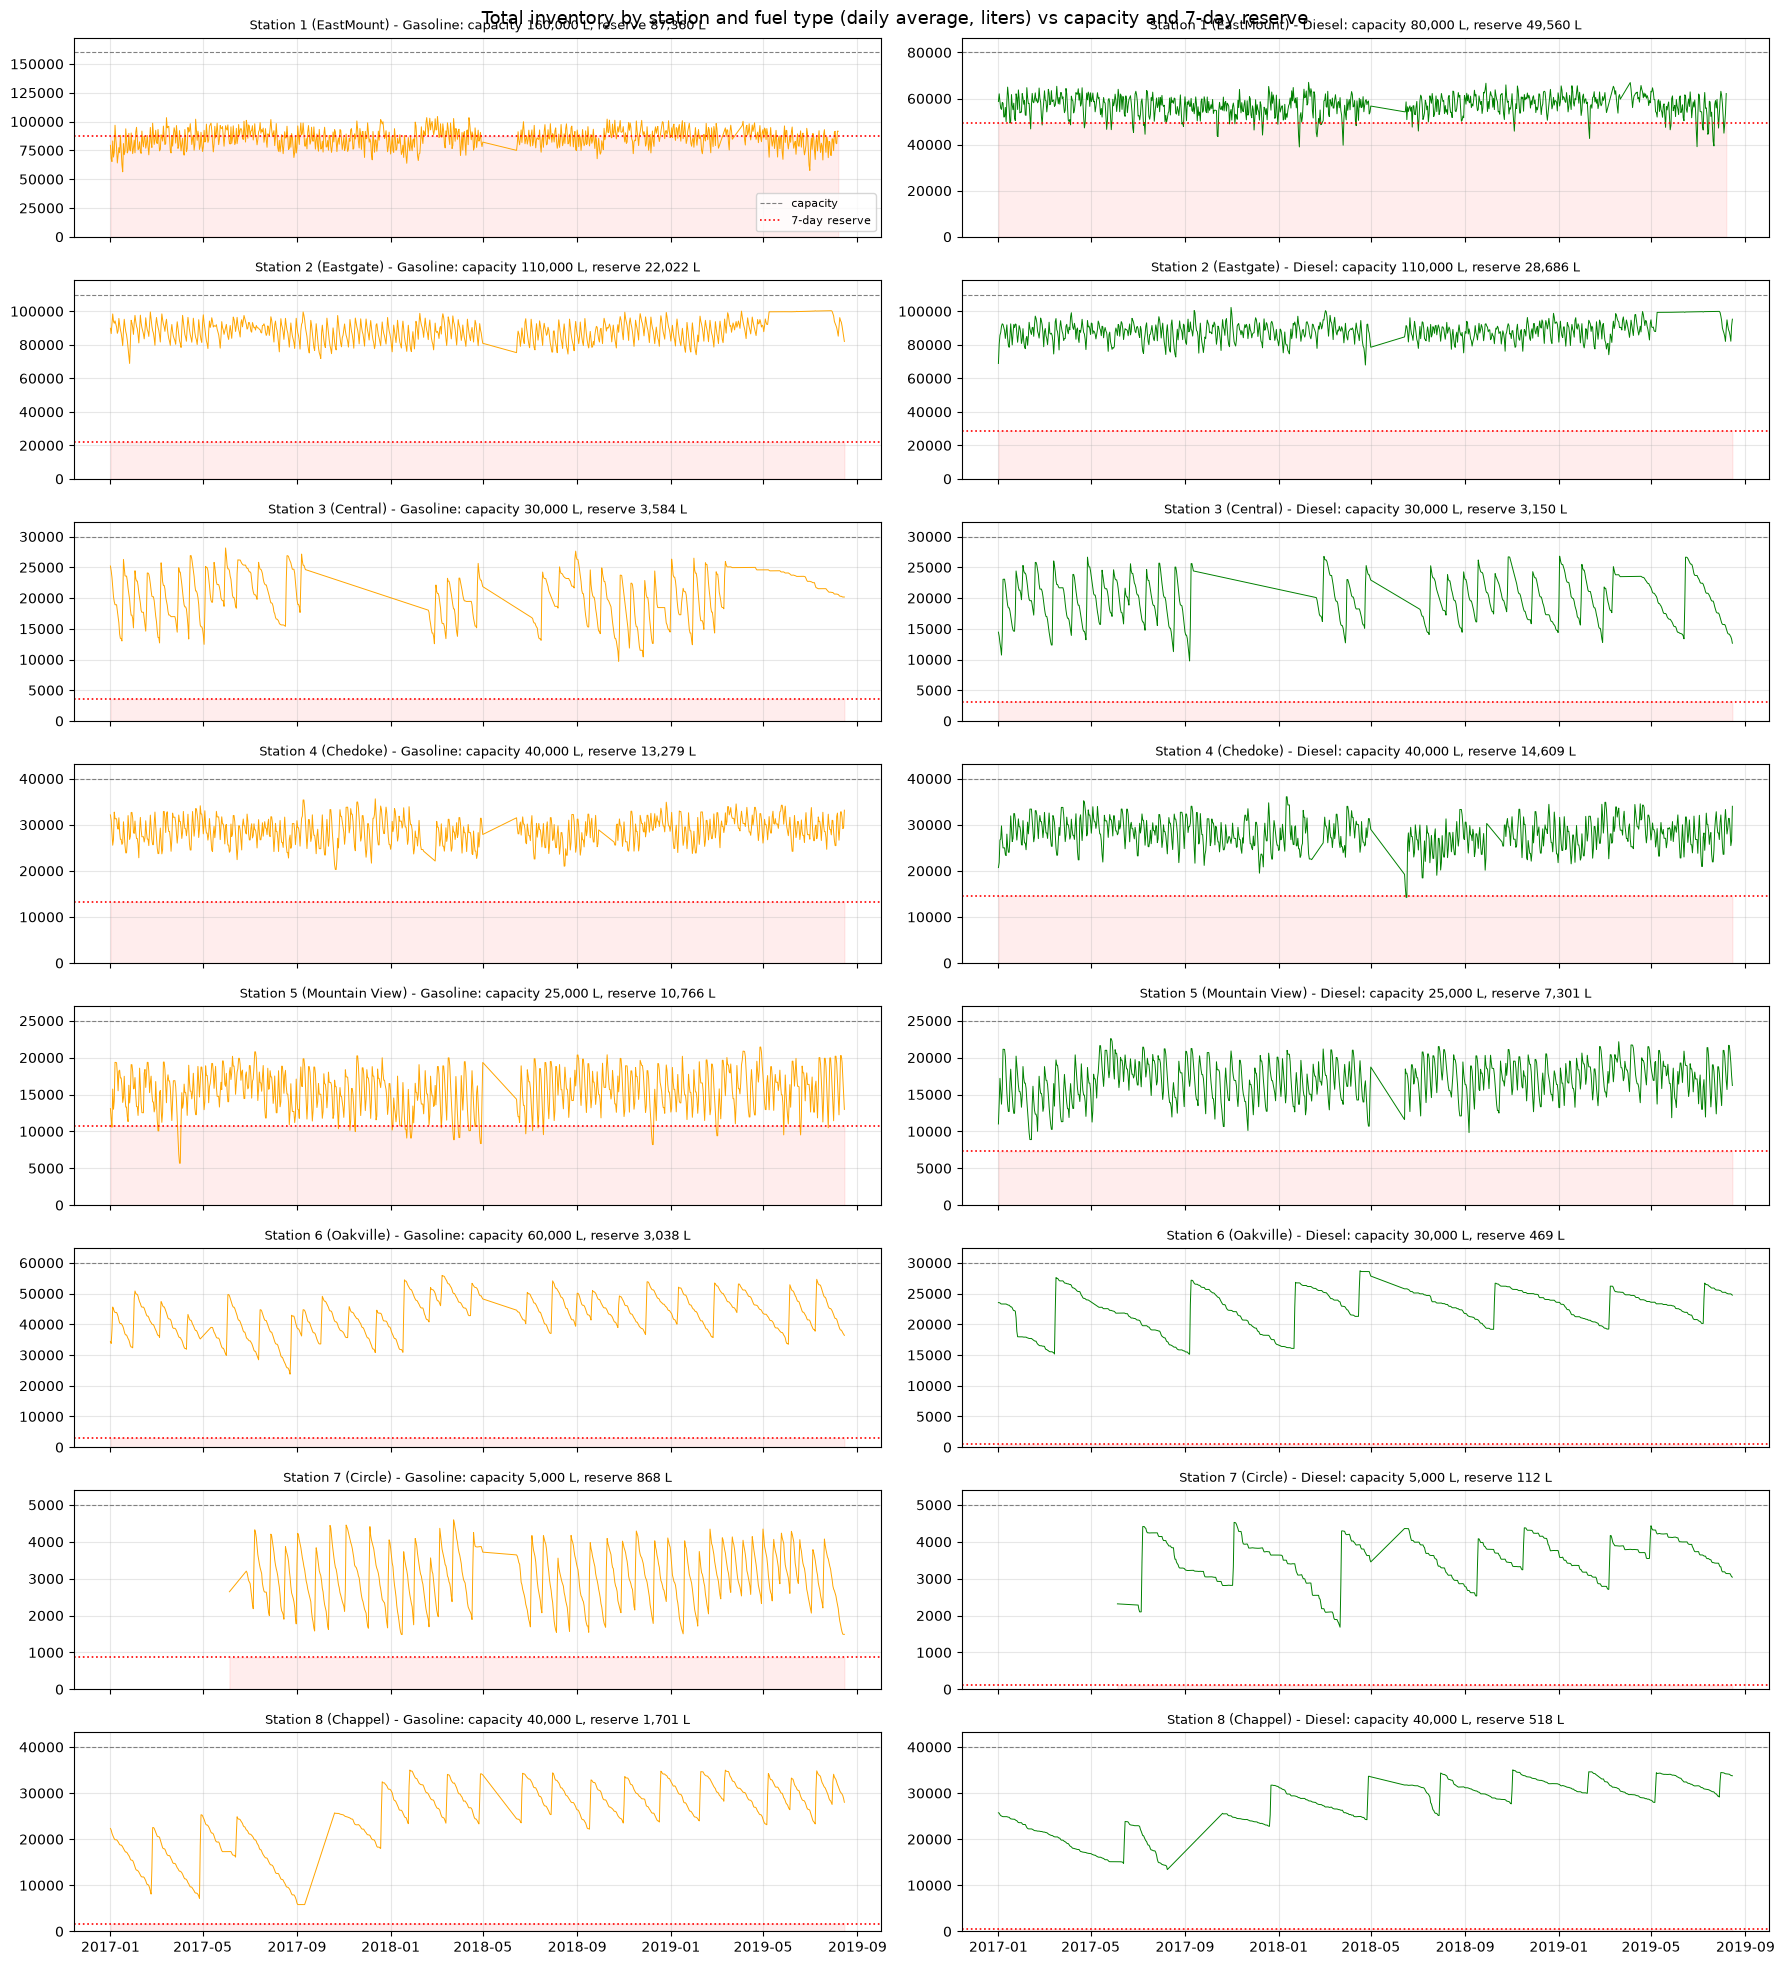

In [21]:
fig, axes = plt.subplots(8, 2, figsize=(18, 20), sharex=True)
for i, station in enumerate(sorted(locations["Station"])):
    for j, fuel in enumerate(["G", "D"]):
        ax = axes[i, j]
        d = daily_level[(daily_level["Station"] == station) & (daily_level["Fuel"] == fuel)]
        r = position.loc[(station, fuel)]
        ax.plot(d["Date"], d["level"], linewidth=0.7, color="orange" if fuel == "G" else "green")
        ax.axhline(r["Capacity"], linestyle="--", color="grey", linewidth=0.8, label="capacity")
        ax.axhline(r["reserve_7d"], linestyle=":", color="red", linewidth=1.2, label="7-day reserve")
        ax.fill_between(d["Date"], 0, r["reserve_7d"], color="red", alpha=0.07)
        ax.set_ylim(0, r["Capacity"] * 1.08); ax.grid(alpha=0.3)
        ax.set_title(f"Station {station} ({names[station]}) - {'Gasoline' if fuel == 'G' else 'Diesel'}: capacity {r['Capacity']:,.0f} L, reserve {r['reserve_7d']:,.0f} L", fontsize=9)
        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Total inventory by station and fuel type (daily average, liters) vs capacity and 7-day reserve", fontsize=13)
plt.tight_layout(); plt.show()

### 2.4 Current purchasing: order sizes, frequency, price and discounts (stations 1 to 8)

Discount saved = liters x discount per liter of that delivery.

In [22]:
months = DAYS / 30.44
current = invoices.groupby(["Station", "Fuel Type"]).agg(
    orders=("Invoice ID", "count"), total_liters=("Liters", "sum"), avg_order=("Liters", "mean"),
    max_order=("Liters", "max"), total_cost=("Cost", "sum"), saved=("Saved", "sum"))
current.index.names = ["Station", "Fuel"]
current["orders_per_month"] = (current["orders"] / months).round(1)
current["avg_rate"] = (current["total_cost"] / current["total_liters"]).round(3)
current["discount_cents_per_L"] = (current["saved"] / current["total_liters"] * 100).round(2)
current.round(0)

orders  total_liters  avg_order  max_order  total_cost     saved  orders_per_month  avg_rate  discount_cents_per_L
Station Fuel                                                                                                                    
1       D        599     4872458.0     8134.0    21198.0   5896560.0    2348.0              19.0       1.0                   0.0
        G        762    10866211.0    14260.0    33827.0  12302393.0  188240.0              24.0       1.0                   2.0
2       D        347     3460900.0     9974.0    23461.0   4015548.0    6761.0              11.0       1.0                   0.0
        G        285     2822514.0     9904.0    18365.0   3040002.0    3535.0               9.0       1.0                   0.0
3       D         41      431815.0    10532.0    15972.0    492978.0     319.0               1.0       1.0                   0.0
        G         39      423519.0    10859.0    17665.0    447329.0    1636.0               1.0       1.0                   0.0
4       D        184     1632468.0     8872.0    17168.0   1967561.0     343.0               6.0       1.0                   0.0
        G        172     1578618.0     9178.0    13310.0   1730773.0       0.0               6.0       1.0                   0.0
5       D        125      811734.0     6494.0    11625.0    994681.0       0.0               4.0       1.0                   0.0
        G        155     1346713.0     8688.0    13062.0   1487689.0       0.0               5.0       1.0                   0.0
6       D          7       54630.0     7804.0    11863.0     66018.0       0.0               0.0       1.0                   0.0
        G         35      386680.0    11048.0    21440.0    419757.0    1462.0               1.0       1.0                   0.0
7       D          8       11082.0     1385.0     2499.0     13196.0       0.0               0.0       1.0                   0.0
        G         44       93563.0     2126.0     3060.0    104159.0       0.0               1.0       1.0                   0.0
8       D          9       76051.0     8450.0    24454.0     87485.0     489.0               0.0       1.0                   1.0
        G         19      207743.0    10934.0    23353.0    232598.0     846.0               1.0       1.0                   0.0

In [23]:
# share of deliveries in each discount tier
tier_share = pd.crosstab([invoices["Station"], invoices["Fuel Type"]], invoices["Tier"], normalize="index")
tier_share = tier_share[["<15k (0c)", "15k-25k (2c)", "25k-40k (3c)"]]   # nobody reached 40k+
(tier_share * 100).round(0)

Tier               <15k (0c)  15k-25k (2c)  25k-40k (3c)
Station Fuel Type                                       
1       D               99.0           1.0           0.0
        G               65.0          11.0          23.0
2       D               94.0           6.0           0.0
        G               96.0           4.0           0.0
3       D               98.0           2.0           0.0
        G               87.0          13.0           0.0
4       D               99.0           1.0           0.0
        G              100.0           0.0           0.0
5       D              100.0           0.0           0.0
        G              100.0           0.0           0.0
6       D              100.0           0.0           0.0
        G               89.0          11.0           0.0
7       D              100.0           0.0           0.0
        G              100.0           0.0           0.0
8       D               89.0          11.0           0.0
        G               89.0          11.0           0.0

Network total: 29,076,698 L bought for CAD 33,298,726
Discount saved: CAD 205,979 = 0.71 cents per liter
Deliveries below 15,000 L: 89% of deliveries, 73% of volume
Biggest single delivery: 33,827 L


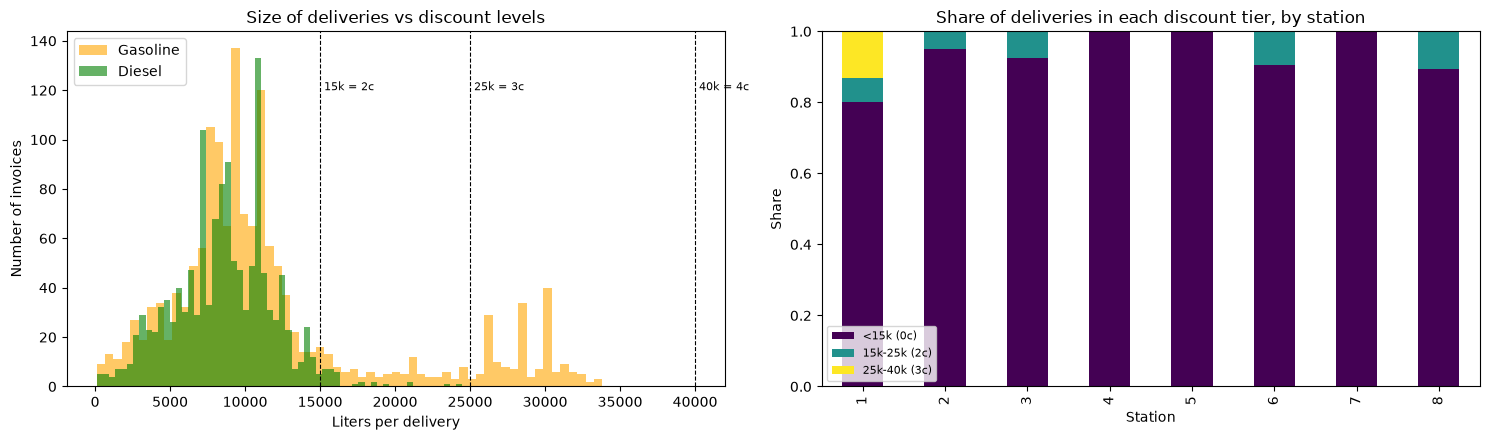

In [24]:
total_liters = invoices["Liters"].sum()
print(f"Network total: {total_liters:,.0f} L bought for CAD {invoices['Cost'].sum():,.0f}")
print(f"Discount saved: CAD {invoices['Saved'].sum():,.0f} = {invoices['Saved'].sum() / total_liters * 100:.2f} cents per liter")
print(f"Deliveries below 15,000 L: {(invoices['Liters'] < 15000).mean() * 100:.0f}% of deliveries, "
      f"{invoices.loc[invoices['Liters'] < 15000, 'Liters'].sum() / total_liters * 100:.0f}% of volume")
print(f"Biggest single delivery: {invoices['Liters'].max():,.0f} L")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].hist(invoices[invoices["Fuel Type"] == "G"]["Liters"], bins=60, alpha=0.6, color="orange", label="Gasoline")
axes[0].hist(invoices[invoices["Fuel Type"] == "D"]["Liters"], bins=60, alpha=0.6, color="green", label="Diesel")
for x, label in [(15000, "2c"), (25000, "3c"), (40000, "4c")]:
    axes[0].axvline(x, linestyle="--", color="black", linewidth=0.8)
    axes[0].text(x, 120, f" {x//1000}k = {label}", fontsize=8)
axes[0].set_title("Size of deliveries vs discount levels"); axes[0].set_xlabel("Liters per delivery"); axes[0].set_ylabel("Number of invoices"); axes[0].legend()
share_station = pd.crosstab(invoices["Station"], invoices["Tier"], normalize="index")[["<15k (0c)", "15k-25k (2c)", "25k-40k (3c)"]]
share_station.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Share of deliveries in each discount tier, by station"); axes[1].set_ylabel("Share"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 2.5 What we learned from Question 1

* **The network buys small and often.** 89% of deliveries are below 15,000 L and get no discount. Only 6% reach 25,000 L and none reached 40,000 L (the biggest was 33,827 L). Over 956 days the discounts earned were CAD 205,979, about 0.7 cents per liter. Only station 1 gasoline gets discounts regularly (23% of its orders in the 3-cent tier).
* **Station 1 (EastMount) is the one with stockout risk.** It gets a delivery almost every day (24 gasoline and 19 diesel orders per month), but its gasoline inventory was below the 7-day reserve 53% of the time, with a minimum of about 3 days of fuel. Diesel was below the reserve 12% of the time.
* **Station 5 gasoline** is the second risk: inventory below the reserve 10% of the time, minimum about 3 days.
* **Stations 2, 3, 6 and 8 hold much more fuel than they need**: on average 15 to 30 days of fuel (station 6 diesel over 200 days). They are never close to running out, but they still order in small amounts and get no discount.
* **Demand** goes from about 12,500 L of gasoline per day at station 1 down to under 20 L of diesel per day at station 7.
* Station 1 seems to use two of its gasoline tanks (T10 and T13) one at a time: one of them is always flat while the other is active. This doesn't change the station-level numbers but means its real gasoline capacity is closer to 120,000 L than 160,000 L.

## 3. Question 2: A better ordering policy

### 3.1 Capacity, consumption, reserve and available space

For each station and fuel type:

* reserve = 7 x average daily consumption
* available space = total capacity - reserve (because the order arrives when inventory is at the reserve)
* the best discount we can get = the biggest discount level that fits in the available space

Capacity alone doesn't decide the discount: a 40,000 L station with high demand may only have room for a 25,000 L order after keeping the reserve.

In [25]:
def best_order(available):
    # biggest discount threshold that fits in the available space (0 if none)
    if available >= 40000:
        return 40000
    elif available >= 25000:
        return 25000
    elif available >= 15000:
        return 15000
    else:
        return 0

policy = capacity.set_index(["Station", "Fuel"]).copy()
policy["avg_daily"] = consumption["avg_daily"]
policy["p95_daily"] = consumption["p95_daily"]
policy["reserve_7d"] = (RESERVE_DAYS * policy["avg_daily"]).round(0)
policy["available"] = policy["Capacity"] - policy["reserve_7d"]
policy["reserve_%_of_capacity"] = (policy["reserve_7d"] / policy["Capacity"] * 100).round(0)
policy["feasible"] = policy["available"] > 0
policy["best_order"] = policy["available"].apply(best_order)
policy["best_discount"] = policy["best_order"].apply(discount_rate)
print("Station/fuel pairs where the reserve is bigger than the capacity:", (~policy["feasible"]).sum())
policy

Station/fuel pairs where the reserve is bigger than the capacity: 0


Capacity  avg_daily  p95_daily  reserve_7d  available  reserve_%_of_capacity  feasible  best_order  best_discount
Station Fuel                                                                                                                   
1       D        80000     7080.0    10990.0     49560.0    30440.0                   62.0      True       25000           0.03
        G       160000    12480.0    16641.0     87360.0    72640.0                   55.0      True       40000           0.04
2       D       110000     4098.0     7579.0     28686.0    81314.0                   26.0      True       40000           0.04
        G       110000     3146.0     5103.0     22022.0    87978.0                   20.0      True       40000           0.04
3       D        30000      450.0     1194.0      3150.0    26850.0                   10.0      True       25000           0.03
        G        30000      512.0     1734.0      3584.0    26416.0                   12.0      True       25000           0.03
4       D        40000     2087.0     4833.0     14609.0    25391.0                   37.0      True       25000           0.03
        G        40000     1897.0     3505.0     13279.0    26721.0                   33.0      True       25000           0.03
5       D        25000     1043.0     2296.0      7301.0    17699.0                   29.0      True       15000           0.02
        G        25000     1538.0     2940.0     10766.0    14234.0                   43.0      True           0           0.00
6       D        30000       67.0      297.0       469.0    29531.0                    2.0      True       25000           0.03
        G        60000      434.0      997.0      3038.0    56962.0                    5.0      True       40000           0.04
7       D         5000       16.0      108.0       112.0     4888.0                    2.0      True           0           0.00
        G         5000      124.0      271.0       868.0     4132.0                   17.0      True           0           0.00
8       D        40000       74.0      348.0       518.0    39482.0                    1.0      True       25000           0.03
        G        40000      243.0      599.0      1701.0    38299.0                    4.0      True       25000           0.03

### 3.2 Comparing order sizes

For each station and fuel type we compare four order sizes: 15,000 L, 25,000 L, 40,000 L and "fill up" (order exactly the available space). An option is feasible only if it fits in the available space. For each one we show the discount, the number of days between orders (order size / daily consumption) and the discount savings it would give on the liters the station actually bought.

In [26]:
rows = []
for (station, fuel), r in policy.iterrows():
    liters_bought = current.loc[(station, fuel), "total_liters"]
    for name, q in [("15,000 L", 15000), ("25,000 L", 25000), ("40,000 L", 40000), ("fill up", r["available"])]:
        feasible = (q <= r["available"]) and (q > 0)
        rows.append({"Station": station, "Fuel": fuel, "Option": name, "Order size": round(q),
                     "Feasible": feasible,
                     "Discount": discount_rate(q) if feasible else None,
                     "Days between orders": round(q / r["avg_daily"], 1) if feasible else None,
                     "Savings on bought liters": round(liters_bought * discount_rate(q)) if feasible else None})
options = pd.DataFrame(rows)
options.pivot(index=["Station", "Fuel"], columns="Option", values="Savings on bought liters")

Option        15,000 L  25,000 L  40,000 L   fill up
Station Fuel                                        
1       D      97449.0  146174.0       NaN  146174.0
        G     217324.0  325986.0  434648.0  434648.0
2       D      69218.0  103827.0  138436.0  138436.0
        G      56450.0   84675.0  112901.0  112901.0
3       D       8636.0   12954.0       NaN   12954.0
        G       8470.0   12706.0       NaN   12706.0
4       D      32649.0   48974.0       NaN   48974.0
        G      31572.0   47359.0       NaN   47359.0
5       D      16235.0       NaN       NaN   16235.0
        G          NaN       NaN       NaN       0.0
6       D       1093.0    1639.0       NaN    1639.0
        G       7734.0   11600.0   15467.0   15467.0
7       D          NaN       NaN       NaN       0.0
        G          NaN       NaN       NaN       0.0
8       D       1521.0    2282.0       NaN    2282.0
        G       4155.0    6232.0       NaN    6232.0

In [27]:
options.pivot(index=["Station", "Fuel"], columns="Option", values="Days between orders")

Option        15,000 L  25,000 L  40,000 L  fill up
Station Fuel                                       
1       D          2.1       3.5       NaN      4.3
        G          1.2       2.0       3.2      5.8
2       D          3.7       6.1       9.8     19.8
        G          4.8       7.9      12.7     28.0
3       D         33.3      55.6       NaN     59.7
        G         29.3      48.8       NaN     51.6
4       D          7.2      12.0       NaN     12.2
        G          7.9      13.2       NaN     14.1
5       D         14.4       NaN       NaN     17.0
        G          NaN       NaN       NaN      9.3
6       D        223.9     373.1       NaN    440.8
        G         34.6      57.6      92.2    131.2
7       D          NaN       NaN       NaN    305.5
        G          NaN       NaN       NaN     33.3
8       D        202.7     337.8       NaN    533.5
        G         61.7     102.9       NaN    157.6

### 3.3 Our recommended policy

**Rule:** order when inventory reaches the 7-day reserve, and order the *smallest* amount that gets the best discount that fits. Bigger orders in the same discount level get the same discount per liter but tie up more cash. Where no discount level fits (station 7, station 5 gasoline), we fill up, because there is no discount to get anyway.

We compare three numbers on the **same liters** that each station actually bought:

* current savings = the discounts they actually got
* policy savings = liters x the discount our policy gets
* upper bound = liters x 4 cents (only possible if every order is 40,000 L or more, which doesn't fit at most stations)

In [28]:
recommend = policy.copy()
recommend["order_size"] = np.where(recommend["best_order"] > 0, recommend["best_order"], recommend["available"])
recommend["discount"] = recommend["order_size"].apply(discount_rate)
recommend["trigger"] = recommend["reserve_7d"]
recommend["days_between_orders"] = (recommend["order_size"] / recommend["avg_daily"]).round(1)
recommend["liters_bought"] = current["total_liters"]
recommend["current_savings"] = current["saved"]
recommend["policy_savings"] = recommend["liters_bought"] * recommend["discount"]      # keep full precision, round only when showing
recommend["upper_bound"] = recommend["liters_bought"] * 0.04
recommend["extra_savings"] = recommend["policy_savings"] - recommend["current_savings"]
recommend["extra_per_year"] = (recommend["extra_savings"] * 365 / DAYS).round(0)
recommend["liters_per_year"] = (recommend["liters_bought"] * 365 / DAYS).round(0)

show = ["Capacity", "avg_daily", "trigger", "available", "order_size", "discount", "days_between_orders",
        "liters_bought", "current_savings", "policy_savings", "upper_bound", "extra_savings", "extra_per_year"]
recommend[show].round(0)

Capacity  avg_daily  trigger  available  order_size  discount  days_between_orders  liters_bought  current_savings  policy_savings  \
Station Fuel                                                                                                                                       
1       D        80000     7080.0  49560.0    30440.0     25000.0       0.0                  4.0      4872458.0           2348.0        146174.0   
        G       160000    12480.0  87360.0    72640.0     40000.0       0.0                  3.0     10866211.0         188240.0        434648.0   
2       D       110000     4098.0  28686.0    81314.0     40000.0       0.0                 10.0      3460900.0           6761.0        138436.0   
        G       110000     3146.0  22022.0    87978.0     40000.0       0.0                 13.0      2822514.0           3535.0        112901.0   
3       D        30000      450.0   3150.0    26850.0     25000.0       0.0                 56.0       431815.0            319.0         12954.0   
        G        30000      512.0   3584.0    26416.0     25000.0       0.0                 49.0       423519.0           1636.0         12706.0   
4       D        40000     2087.0  14609.0    25391.0     25000.0       0.0                 12.0      1632468.0            343.0         48974.0   
        G        40000     1897.0  13279.0    26721.0     25000.0       0.0                 13.0      1578618.0              0.0         47359.0   
5       D        25000     1043.0   7301.0    17699.0     15000.0       0.0                 14.0       811734.0              0.0         16235.0   
        G        25000     1538.0  10766.0    14234.0     14234.0       0.0                  9.0      1346713.0              0.0             0.0   
6       D        30000       67.0    469.0    29531.0     25000.0       0.0                373.0        54630.0              0.0          1639.0   
        G        60000      434.0   3038.0    56962.0     40000.0       0.0                 92.0       386680.0           1462.0         15467.0   
7       D         5000       16.0    112.0     4888.0      4888.0       0.0                306.0        11082.0              0.0             0.0   
        G         5000      124.0    868.0     4132.0      4132.0       0.0                 33.0        93563.0              0.0             0.0   
8       D        40000       74.0    518.0    39482.0     25000.0       0.0                338.0        76051.0            489.0          2282.0   
        G        40000      243.0   1701.0    38299.0     25000.0       0.0                103.0       207743.0            846.0          6232.0   

              upper_bound  extra_savings  extra_per_year  
Station Fuel                                              
1       D        194898.0       143826.0         54913.0  
        G        434648.0       246409.0         94079.0  
2       D        138436.0       131675.0         50273.0  
        G        112901.0       109366.0         41756.0  
3       D         17273.0        12635.0          4824.0  
        G         16941.0        11070.0          4226.0  
4       D         65299.0        48631.0         18567.0  
        G         63145.0        47359.0         18081.0  
5       D         32469.0        16235.0          6198.0  
        G         53869.0            0.0             0.0  
6       D          2185.0         1639.0           626.0  
        G         15467.0        14005.0          5347.0  
7       D           443.0            0.0             0.0  
        G          3743.0            0.0             0.0  
8       D          3042.0         1792.0           684.0  
        G          8310.0         5386.0          2056.0

Current savings:   CAD      205,979
Policy savings:    CAD      996,006
Upper bound:       CAD    1,163,068
Extra savings:     CAD      790,027 over 956 days = about CAD 301,630 per year


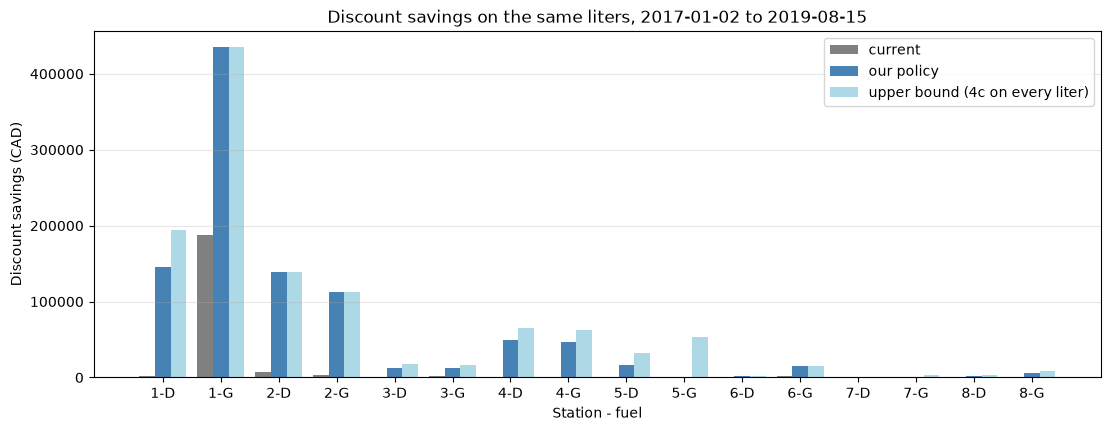

In [29]:
print(f"Current savings:   CAD {recommend['current_savings'].sum():>12,.0f}")
print(f"Policy savings:    CAD {recommend['policy_savings'].sum():>12,.0f}")
print(f"Upper bound:       CAD {recommend['upper_bound'].sum():>12,.0f}")
print(f"Extra savings:     CAD {recommend['extra_savings'].sum():>12,.0f} over {DAYS} days = about CAD {recommend['extra_per_year'].sum():,.0f} per year")

labels = [f"{s}-{f}" for s, f in recommend.index]
x = np.arange(len(labels)); w = 0.27
plt.figure(figsize=(13, 4.5))
plt.bar(x - w, recommend["current_savings"], w, label="current", color="grey")
plt.bar(x, recommend["policy_savings"], w, label="our policy", color="steelblue")
plt.bar(x + w, recommend["upper_bound"], w, label="upper bound (4c on every liter)", color="lightblue")
plt.xticks(x, labels); plt.xlabel("Station - fuel"); plt.ylabel("Discount savings (CAD)")
plt.title(f"Discount savings on the same liters, {START.date()} to {END.date()}"); plt.legend(); plt.grid(alpha=0.3, axis="y")
plt.show()

### 3.4 Checking the policy day by day

To make sure the rule really keeps inventory above the reserve, we replay it against the actual daily consumption. Each day: if today's sales would take inventory below the reserve, we order (the order arrives right away). Then we subtract the day's sales. We count orders, the lowest inventory and the discounts earned. Days with missing readings use the average consumption.

In [30]:
def simulate(station, fuel, keep_path=False):
    r = recommend.loc[(station, fuel)]
    d = daily[(daily["Station"] == station) & (daily["Fuel"] == fuel)].set_index("Date")
    demand = d["sold"].where(d["complete"], r["avg_daily"])
    capacity_ = r["Capacity"]; reserve = r["reserve_7d"]; q = r["order_size"]
    level = capacity_
    orders = 0; ordered = 0; savings = 0; lowest = capacity_; stockouts = 0
    path = []
    for date, sold in demand.items():
        level_at_order = None
        if level - sold < reserve and q > 0:
            amount = min(q, capacity_ - level)
            level_at_order = level
            level = level + amount
            orders += 1; ordered += amount; savings += amount * discount_rate(amount)
        level = level - sold
        if level < 0:
            stockouts += 1; level = 0
        lowest = min(lowest, level)
        path.append({"Date": date, "level": level, "level_at_order": level_at_order})
    result = {"orders": orders, "avg_order": round(ordered / max(orders, 1)), "liters": round(ordered),
              "savings": round(savings), "lowest": round(lowest), "lowest_in_days": round(lowest / r["avg_daily"], 1), "stockout_days": stockouts}
    if keep_path:
        return result, pd.DataFrame(path).set_index("Date")
    return result

sim = pd.DataFrame({key: simulate(*key) for key in recommend.index}).T
sim.index.names = ["Station", "Fuel"]
print("Total simulated savings: CAD", f"{sim['savings'].sum():,.0f}", "| stockout days:", sim["stockout_days"].sum())
sim

Total simulated savings: CAD 1,011,397 | stockout days: 0.0


orders  avg_order      liters   savings   lowest  lowest_in_days  stockout_days
Station Fuel                                                                                 
1       D      254.0    24468.0   6214889.0  172048.0  49562.0             7.0            0.0
        G      274.0    40000.0  10960000.0  438400.0  87380.0             7.0            0.0
2       D       92.0    40000.0   3680000.0  147200.0  28689.0             7.0            0.0
        G       70.0    40000.0   2800000.0  112000.0  22059.0             7.0            0.0
3       D       12.0    25000.0    300000.0    9000.0   3151.0             7.0            0.0
        G       14.0    24900.0    348593.0    9972.0   3623.0             7.1            0.0
4       D       76.0    23885.0   1815264.0   39055.0  14646.0             7.0            0.0
        G       67.0    24755.0   1658609.0   42922.0  13284.0             7.0            0.0
5       D       63.0    15000.0    945000.0   18900.0   7349.0             7.0            0.0
        G      107.0    13027.0   1393844.0       0.0  10778.0             7.0            0.0
6       D        2.0    25000.0     50000.0    1500.0    494.0             7.4            0.0
        G        9.0    40000.0    360000.0   14400.0   3118.0             7.2            0.0
7       D        2.0     4854.0      9707.0       0.0    139.0             8.7            0.0
        G       22.0     4059.0     89296.0       0.0    878.0             7.1            0.0
8       D        1.0    25000.0     25000.0     750.0    648.0             8.8            0.0
        G        7.0    25000.0    175000.0    5250.0   1773.0             7.3            0.0

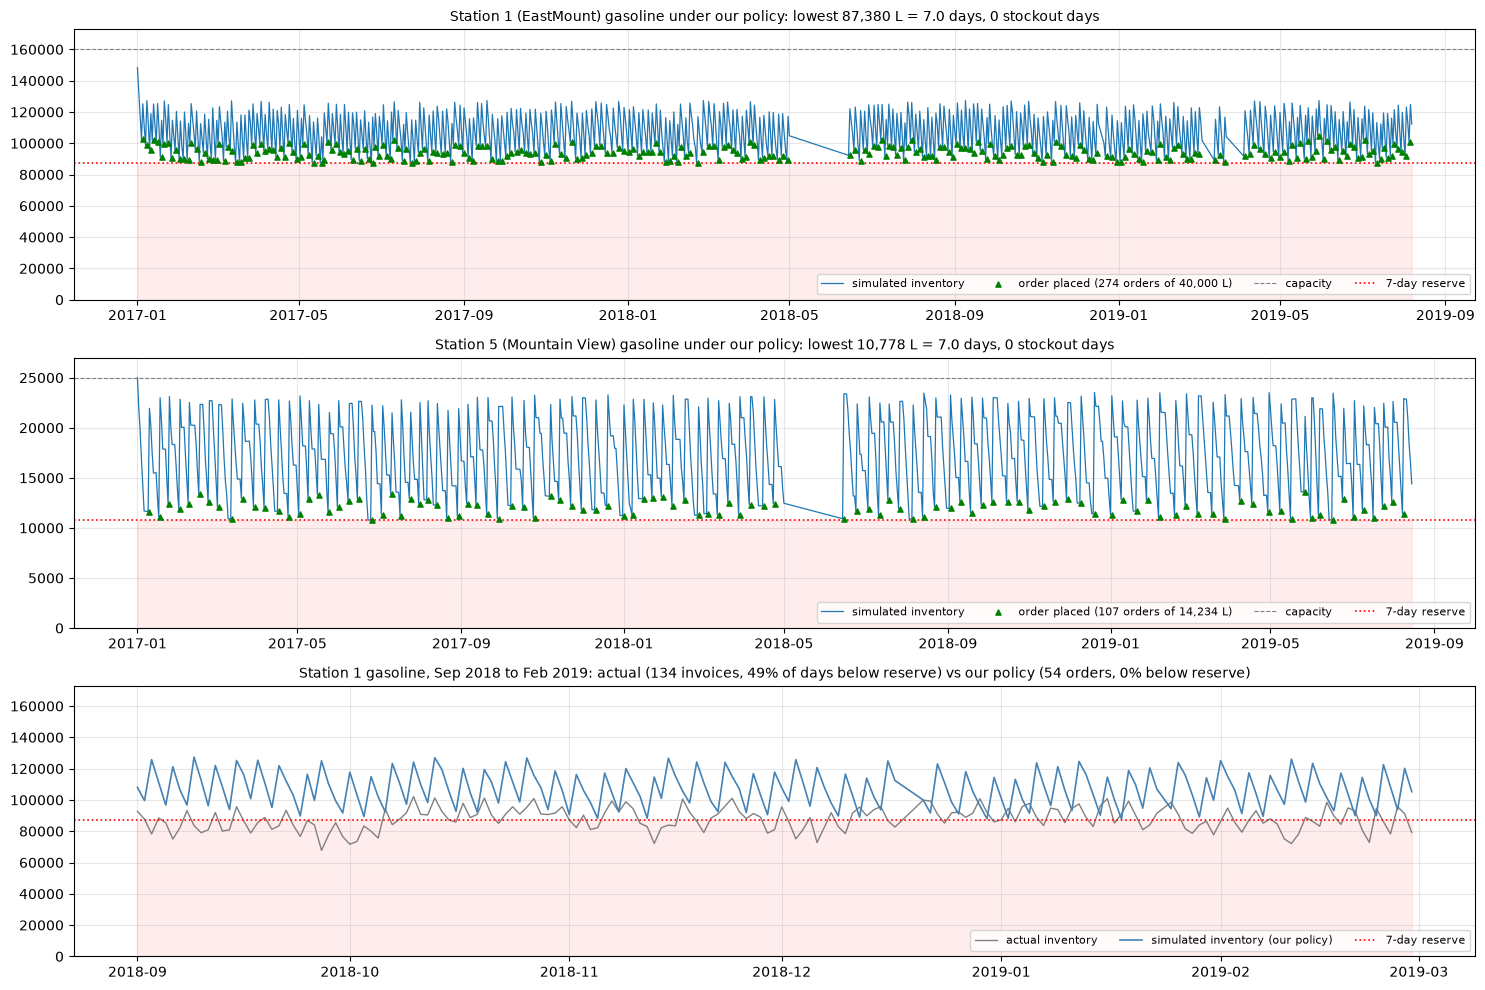

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
for ax, key in zip(axes[:2], [(1, "G"), (5, "G")]):
    result, path = simulate(*key, keep_path=True)
    r = recommend.loc[key]
    ax.plot(path.index, path["level"], linewidth=0.9, label="simulated inventory")
    ordered = path.dropna(subset=["level_at_order"])
    ax.scatter(ordered.index, ordered["level_at_order"], marker="^", s=14, color="green", zorder=5, label=f"order placed ({len(ordered)} orders of {r['order_size']:,.0f} L)")
    ax.axhline(r["Capacity"], linestyle="--", color="grey", linewidth=0.8, label="capacity")
    ax.axhline(r["reserve_7d"], linestyle=":", color="red", linewidth=1.2, label="7-day reserve")
    ax.fill_between(path.index, 0, r["reserve_7d"], color="red", alpha=0.07)
    ax.set_ylim(0, r["Capacity"] * 1.08); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right", ncol=4)
    ax.set_title(f"Station {key[0]} ({names[key[0]]}) gasoline under our policy: lowest {result['lowest']:,} L = {result['lowest_in_days']} days, {result['stockout_days']} stockout days", fontsize=10)

# actual vs simulated for station 1 gasoline, six months
ax = axes[2]; r = recommend.loc[(1, "G")]
result, path = simulate(1, "G", keep_path=True)
actual = daily_level[(daily_level["Station"] == 1) & (daily_level["Fuel"] == "G")].set_index("Date")["level"]
actual = actual["2018-09-01":"2019-02-28"]; path = path["2018-09-01":"2019-02-28"]
n_actual = len(invoices[(invoices["Station"] == 1) & (invoices["Fuel Type"] == "G") & (invoices["Date"] >= "2018-09-01") & (invoices["Date"] <= "2019-02-28")])
n_sim = path["level_at_order"].notnull().sum()
ax.plot(actual.index, actual.values, color="grey", linewidth=1, label="actual inventory")
ax.plot(path.index, path["level"], color="steelblue", linewidth=1.2, label="simulated inventory (our policy)")
ax.axhline(r["reserve_7d"], linestyle=":", color="red", linewidth=1.2, label="7-day reserve")
ax.fill_between(path.index, 0, r["reserve_7d"], color="red", alpha=0.07)
ax.set_ylim(0, r["Capacity"] * 1.08); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right", ncol=3)
ax.set_title(f"Station 1 gasoline, Sep 2018 to Feb 2019: actual ({n_actual} invoices, {(actual < r['reserve_7d']).mean() * 100:.0f}% of days below reserve) vs our policy ({n_sim} orders, 0% below reserve)", fontsize=10)
plt.tight_layout(); plt.show()

### 3.5 Demand variability and delivery time

The description says orders arrive immediately, so ordering exactly at the reserve can never cause a stockout. In real life a delivery can take a day. The table shows what happens if we order one day earlier (trigger = reserve + one day of 95th percentile demand): the available space gets smaller by the same amount, and at some stations that drops the discount by one level.

In [32]:
lead = recommend[["avg_daily", "p95_daily", "reserve_7d", "available", "discount"]].copy()
lead["p95 / avg"] = (lead["p95_daily"] / lead["avg_daily"]).round(2)
lead["trigger_1day_early"] = lead["reserve_7d"] + lead["p95_daily"]
lead["available_1day_early"] = lead["available"] - lead["p95_daily"]
lead["discount_1day_early"] = lead["available_1day_early"].apply(best_order).apply(discount_rate)
lead["loses a level"] = lead["discount_1day_early"] < lead["discount"]
lead.round(0)

avg_daily  p95_daily  reserve_7d  available  discount  p95 / avg  trigger_1day_early  available_1day_early  discount_1day_early  \
Station Fuel                                                                                                                                    
1       D        7080.0    10990.0     49560.0    30440.0       0.0        2.0             60550.0               19450.0                  0.0   
        G       12480.0    16641.0     87360.0    72640.0       0.0        1.0            104001.0               55999.0                  0.0   
2       D        4098.0     7579.0     28686.0    81314.0       0.0        2.0             36265.0               73735.0                  0.0   
        G        3146.0     5103.0     22022.0    87978.0       0.0        2.0             27125.0               82875.0                  0.0   
3       D         450.0     1194.0      3150.0    26850.0       0.0        3.0              4344.0               25656.0                  0.0   
        G         512.0     1734.0      3584.0    26416.0       0.0        3.0              5318.0               24682.0                  0.0   
4       D        2087.0     4833.0     14609.0    25391.0       0.0        2.0             19442.0               20558.0                  0.0   
        G        1897.0     3505.0     13279.0    26721.0       0.0        2.0             16784.0               23216.0                  0.0   
5       D        1043.0     2296.0      7301.0    17699.0       0.0        2.0              9597.0               15403.0                  0.0   
        G        1538.0     2940.0     10766.0    14234.0       0.0        2.0             13706.0               11294.0                  0.0   
6       D          67.0      297.0       469.0    29531.0       0.0        4.0               766.0               29234.0                  0.0   
        G         434.0      997.0      3038.0    56962.0       0.0        2.0              4035.0               55965.0                  0.0   
7       D          16.0      108.0       112.0     4888.0       0.0        7.0               220.0                4780.0                  0.0   
        G         124.0      271.0       868.0     4132.0       0.0        2.0              1139.0                3861.0                  0.0   
8       D          74.0      348.0       518.0    39482.0       0.0        5.0               866.0               39134.0                  0.0   
        G         243.0      599.0      1701.0    38299.0       0.0        2.0              2300.0               37700.0                  0.0   

              loses a level  
Station Fuel                 
1       D              True  
        G             False  
2       D             False  
        G             False  
3       D             False  
        G              True  
4       D              True  
        G              True  
5       D             False  
        G             False  
6       D             False  
        G             False  
7       D             False  
        G             False  
8       D             False  
        G             False

### 3.6 What we learned from Question 2

* The 7-day reserve fits in every station's tanks, but it takes a lot of the space at the busy stations: 62% of diesel capacity and 55% of gasoline capacity at station 1, and 43% of gasoline capacity at station 5. Station 7's two 5,000 L tanks leave only 4,000 to 5,000 L of space, so no discount is possible there.
* **Recommended orders:** 40,000 L at station 1 (gasoline), station 2 (both fuels) and station 6 (gasoline); 25,000 L at station 1 (diesel), stations 3, 4 and 8 (both fuels) and station 6 (diesel); 15,000 L at station 5 (diesel); fill up with no discount at station 5 (gasoline) and station 7. Station 5 gasoline misses the 2-cent level by only 768 L of space; a 6.5-day reserve would unlock about CAD 10,000 a year, but that would break the rule in the description, so we only mention it.
* **Savings:** on the same liters, discounts go from CAD 205,979 to CAD 996,006 (the upper bound with 4 cents on everything is CAD 1,163,068). That is CAD 790,027 extra over 956 days, about **CAD 302,000 per year**. The day-by-day replay gives CAD 1,011,397 of discounts with zero stockout days and never less than 7 days of fuel.
* **Fewer deliveries:** station 1 goes from about 43 deliveries a month to 18, station 2 from 20 to 6, station 4 from 11 to 5.
* **Station 4 and station 5 are borderline cases.** Station 4's available space (25,400 L diesel, 26,700 L gasoline) is only just above the 25,000 L threshold for the 3-cent level: if diesel demand were 2,143 L/day instead of our 2,087 (2.7% higher), station 4 diesel would drop to the 2-cent level. Station 5 gasoline is 768 L short of the 2-cent level and would reach it if demand were 7% lower (1,429 L/day). We re-estimated consumption with a second method (different smoothing and a different way of adding up the daily drops) and got numbers within 3% of these, so the tiers hold, but these two stations should be re-checked with newer data.
* **Variability:** on a busy day demand is 1.3 to 1.6 times the average at the big stations, and 2 to 7 times at the small ones (one fleet fill-up is a big day there). If we order one day early to cover a real delivery time, station 1 diesel, station 3 gasoline and station 4 (both fuels) drop from 3 cents to 2 cents. Those are the places where management has to choose between discount and safety.
* **Very low demand:** at stations 6, 7 and 8 diesel the recommended order would last 10 to 12 months. The discount at stake is under CAD 1,000 a year in total, so in practice they should order about 90 days of fuel at a time to avoid old fuel, and give up the discount.

## 4. Question 3: Are prices different on different days of the week?

### 4.1 Box plots of the rate, Monday to Friday

`Rate` = cost / liters. Saturday only has 13 invoices and there are no Sunday invoices, so we compare Monday to Friday and show the number of invoices for each day.

**How we decide:** a box plot shows the whole distribution, not just the average. If one day's box sits clearly below the others, that day was cheaper most of the time and the data support a cheaper day. If the boxes are in the same range and only the medians differ a bit, the day was cheaper only sometimes, and we don't have enough evidence to say it will be cheaper in the future.

In [33]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
by_day = invoices[invoices["Weekday"].isin(weekdays)].groupby("Weekday").agg(
    invoices=("Invoice ID", "count"), mean_rate=("Rate", "mean"), median_rate=("Rate", "median"),
    q25=("Rate", lambda x: x.quantile(0.25)), q75=("Rate", lambda x: x.quantile(0.75)),
    avg_order=("Liters", "mean"), avg_discount=("Discount", "mean")).loc[weekdays]
by_day.round(4)

,invoices,mean_rate,median_rate,q25,q75,avg_order,avg_discount
Weekday,,,,,,,
Monday,522,1.1849,1.0602,1.0213,1.1824,9081.7681,0.0007
Tuesday,549,1.2563,1.0683,1.0312,1.2588,12771.5813,0.0063
Wednesday,606,1.1956,1.0602,1.0213,1.1843,9071.2855,0.0006
Thursday,338,1.1901,1.0602,1.0213,1.1816,9175.7606,0.0008
Friday,803,1.2176,1.0677,1.0213,1.2371,10709.9136,0.0044


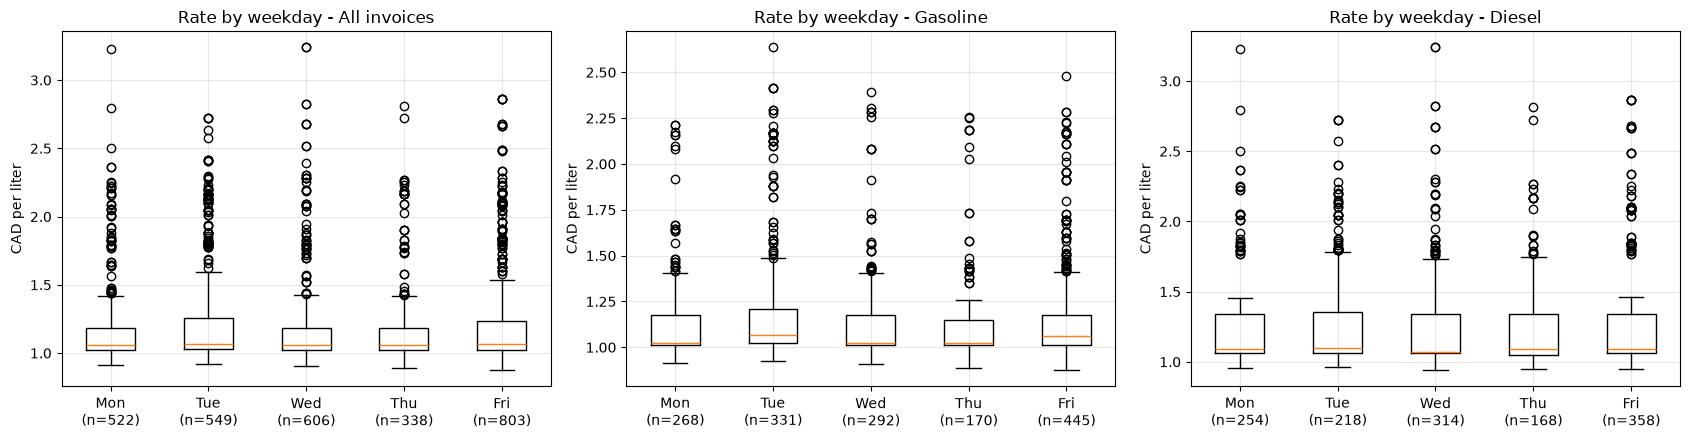

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, title, d in [(axes[0], "All invoices", invoices), (axes[1], "Gasoline", invoices[invoices["Fuel Type"] == "G"]),
                     (axes[2], "Diesel", invoices[invoices["Fuel Type"] == "D"])]:
    data = [d[d["Weekday"] == day]["Rate"] for day in weekdays]
    ax.boxplot(data)
    ax.set_xticks(range(1, 6)); ax.set_xticklabels([f"{day[:3]}\n(n={len(x)})" for day, x in zip(weekdays, data)])
    ax.set_title("Rate by weekday - " + title); ax.set_ylabel("CAD per liter"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The five boxes overlap almost completely in all three charts. The medians are between 1.060 and 1.068 CAD/L. No day's box is below the others.

### 4.2 Checking other explanations

The small differences in the averages could come from other things, so we check them:

* **Price over time.** Every station pays the same price on the same day, and the price moves a lot: flat for months, then almost double in spring 2019. A day that happened to have more orders in expensive months looks more expensive.
* **Fuel type.** Diesel is more expensive than gasoline, so the mix of fuels on each day matters.
* **Order size and discounts.** Tuesday orders are bigger on average (12,800 L vs about 9,000 L), so they get more discount. We use the price *before* discount to compare.
* **Same month comparison.** To remove the price trend, we compare each invoice to the median price of the same fuel in the same month.

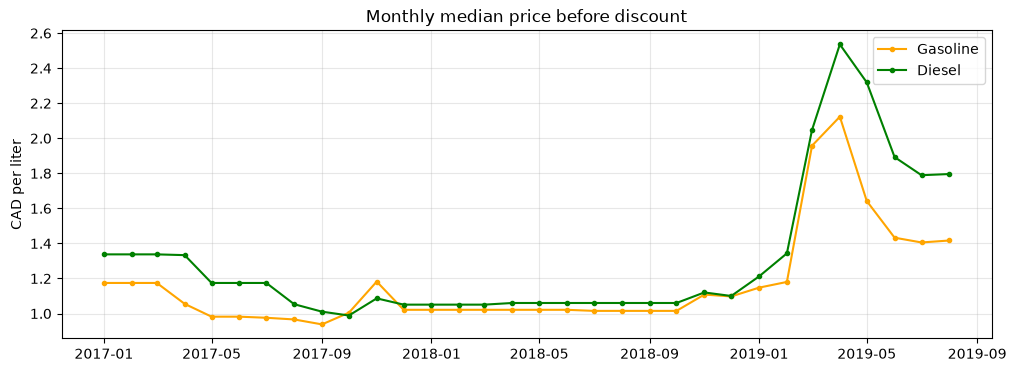

Median std of the price across stations on the same day: 0.0 -> all stations pay the same price on a day


In [35]:
monthly = invoices.groupby(["Fuel Type", pd.Grouper(key="Date", freq="MS")])["Rate_before_discount"].median().unstack("Fuel Type")
plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly["G"], marker="o", markersize=3, color="orange", label="Gasoline")
plt.plot(monthly.index, monthly["D"], marker="o", markersize=3, color="green", label="Diesel")
plt.title("Monthly median price before discount"); plt.ylabel("CAD per liter"); plt.legend(); plt.grid(alpha=0.3); plt.show()

same_day = invoices.groupby(["Date", "Fuel Type"])["Rate_before_discount"].std()
print("Median std of the price across stations on the same day:", round(same_day.median(), 5), "-> all stations pay the same price on a day")

Mean difference from the same-month median price (cents per liter):
Fuel Type     D     G
Weekday              
Monday     0.01 -1.07
Tuesday   -0.82  2.37
Wednesday  0.33  0.00
Thursday  -0.84 -0.36
Friday    -0.19  1.28

Same thing by year:
Weekday  Monday  Tuesday  Wednesday  Thursday  Friday
Year                                                 
2017      -0.39     1.32      -0.82     -0.39    0.59
2018       0.09     1.73       0.02     -0.09    1.19
2019      -2.08    -0.17       2.57     -2.19   -0.25

Median difference by weekday:
Weekday
Monday       0.0
Tuesday      0.0
Wednesday    0.0
Thursday     0.0
Friday       0.0
Name: vs_month_median_cents, dtype: float64


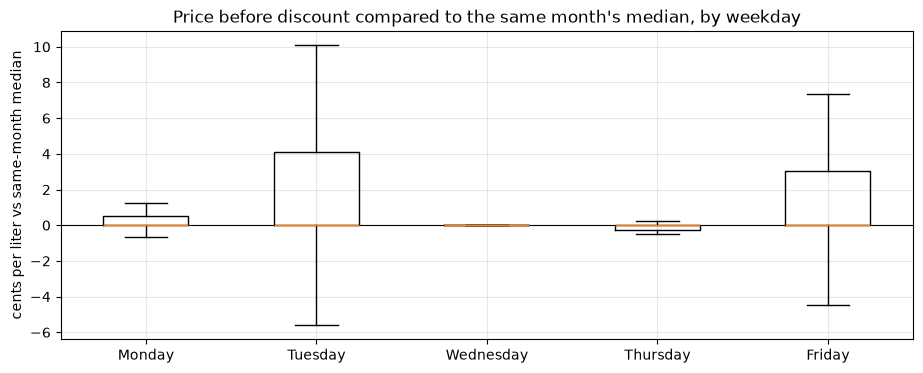

In [36]:
invoices["Month"] = invoices["Date"].dt.to_period("M")
invoices["Year"] = invoices["Date"].dt.year
month_median = invoices.groupby(["Fuel Type", "Month"])["Rate_before_discount"].transform("median")
invoices["vs_month_median_cents"] = (invoices["Rate_before_discount"] - month_median) * 100

mon_fri = invoices[invoices["Weekday"].isin(weekdays)]
print("Mean difference from the same-month median price (cents per liter):")
print(mon_fri.pivot_table(index="Weekday", columns="Fuel Type", values="vs_month_median_cents", aggfunc="mean").loc[weekdays].round(2))
print("\nSame thing by year:")
print(mon_fri.pivot_table(index="Year", columns="Weekday", values="vs_month_median_cents", aggfunc="mean")[weekdays].round(2))
print("\nMedian difference by weekday:")
print(mon_fri.groupby("Weekday")["vs_month_median_cents"].median().loc[weekdays].round(2))

plt.figure(figsize=(11, 4))
plt.boxplot([mon_fri[mon_fri["Weekday"] == day]["vs_month_median_cents"] for day in weekdays], showfliers=False)
plt.xticks(range(1, 6), weekdays); plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("cents per liter vs same-month median"); plt.title("Price before discount compared to the same month's median, by weekday")
plt.grid(alpha=0.3); plt.show()

### 4.3 What we learned from Question 3

* **No weekday is cheaper.** The Monday-to-Friday boxes overlap and their medians are within one cent. After removing the price trend and the discounts, the median difference is zero for every day. By our decision rule there is not enough evidence for a cheaper day. The idea that one day is cheaper is, on this data, a rumour.
* The only thing we noticed is that Tuesday's *average* is about 1.5 to 2 cents higher than the other days in 2017 and 2018 (it looks like price increases were often posted on Tuesdays), but the Tuesday box still overlaps the others and the pattern disappears in 2019. "Sometimes, not most of the time", so we don't base anything on it.
* **Savings:** because no day is cheaper, we add **no weekday savings** to our recommendations. If Tuesday really were 1.6 cents more expensive, the most the network could save by moving Tuesday orders would be about CAD 40,000 a year, and only at stations whose order schedule can move by a day without losing a discount level (not station 1 diesel). We mention this only as an upper limit.
* **Limits:** only 13 Saturday invoices and no Sundays; every station pays the same price on a day, so the real sample size is the number of order days, not the number of invoices; and the 2019 price jump dominates any raw comparison.

## 5. Question 4: Is it worth replacing a tank?

### 5.1 Method

At each station we try replacing each existing tank with a 60,000 L tank for the same fuel, at CAD 250,000. We only count replacements that make the tank bigger (station 2's two 70,000 L tanks would not get bigger). For each one:

* extra space = 60,000 - old capacity
* new available space = new capacity - the same 7-day reserve, and the new discount level that fits
* extra savings per year = liters per year x (new discount - discount under our policy with the old tanks). This is compared to our improved policy, not to today.
* 5-year net benefit = 5 x extra savings per year - 250,000 (we assume no extra operating cost)
* payback = 250,000 / extra savings per year

Liters per year = liters bought in the 956 days x 365 / 956. Prices, discounts and demand are kept constant for 5 years.

In [37]:
rows = []
for _, t in tanks.iterrows():
    r = recommend.loc[(t["Station"], t["Fuel"])]
    extra = NEW_TANK - t["Tank Capacity"]
    row = {"Station": t["Station"], "Tank": t["Tank ID"], "Fuel": t["Fuel"], "old_capacity": t["Tank Capacity"],
           "extra_space": max(extra, 0), "available_before": r["available"], "discount_before": r["discount"], "liters_per_year": r["liters_per_year"],
           "station_capacity": r["Capacity"], "avg_daily": r["avg_daily"]}
    if extra <= 0:
        row.update({"available_after": r["available"], "discount_after": r["discount"], "extra_savings_per_year": 0, "note": "60,000 L is not bigger - no increase"})
    else:
        available_after = r["available"] + extra
        discount_after = discount_rate(best_order(available_after))
        row.update({"available_after": available_after, "discount_after": discount_after,
                    "extra_savings_per_year": round(r["liters_per_year"] * (discount_after - r["discount"])), "note": ""})
    rows.append(row)
candidates = pd.DataFrame(rows)
candidates["five_year_net"] = np.where(candidates["extra_space"] > 0, YEARS * candidates["extra_savings_per_year"] - NEW_TANK_COST, 0)
candidates["payback_years"] = np.where(candidates["extra_savings_per_year"] > 0, NEW_TANK_COST / candidates["extra_savings_per_year"].replace(0, np.nan), np.nan).round(1)
candidates

,Station,Tank,Fuel,old_capacity,extra_space,available_before,discount_before,liters_per_year,station_capacity,avg_daily,available_after,discount_after,extra_savings_per_year,note,five_year_net,payback_years
0,1,T10,G,40000,20000,72640.0,0.04,4148710.0,160000,12480.0,92640.0,0.04,0,,-250000,NaN
1,1,T11,G,40000,20000,72640.0,0.04,4148710.0,160000,12480.0,92640.0,0.04,0,,-250000,NaN
2,1,T12,D,40000,20000,30440.0,0.03,1860300.0,80000,7080.0,50440.0,0.04,18603,,-156985,13.4
3,1,T13,G,40000,20000,72640.0,0.04,4148710.0,160000,12480.0,92640.0,0.04,0,,-250000,NaN
4,1,T14,G,40000,20000,72640.0,0.04,4148710.0,160000,12480.0,92640.0,0.04,0,,-250000,NaN
5,1,T15,D,40000,20000,30440.0,0.03,1860300.0,80000,7080.0,50440.0,0.04,18603,,-156985,13.4
6,2,T16,G,70000,0,87978.0,0.04,1077633.0,110000,3146.0,87978.0,0.04,0,"60,000 L is not bigger - no increase",0,NaN
7,2,T17,D,40000,20000,81314.0,0.04,1321369.0,110000,4098.0,101314.0,0.04,0,,-250000,NaN
8,2,T18,G,40000,20000,87978.0,0.04,1077633.0,110000,3146.0,107978.0,0.04,0,,-250000,NaN
9,2,T19,D,70000,0,81314.0,0.04,1321369.0,110000,4098.0,81314.0,0.04,0,"60,000 L is not bigger - no increase",0,NaN


In [38]:
# best single replacement per station
best = candidates[candidates["extra_space"] > 0].sort_values(["Station", "extra_savings_per_year"], ascending=[True, False]).groupby("Station").head(1).set_index("Station")
best["days_of_fuel_when_full_before"] = (best["station_capacity"] / best["avg_daily"]).round(0)
best["days_of_fuel_when_full_after"] = ((best["station_capacity"] + best["extra_space"]) / best["avg_daily"]).round(0)
best[["Tank", "Fuel", "old_capacity", "extra_space", "available_before", "available_after", "discount_before", "discount_after",
      "liters_per_year", "extra_savings_per_year", "five_year_net", "payback_years", "days_of_fuel_when_full_before", "days_of_fuel_when_full_after"]]

,Tank,Fuel,old_capacity,extra_space,available_before,available_after,discount_before,discount_after,liters_per_year,extra_savings_per_year,five_year_net,payback_years,days_of_fuel_when_full_before,days_of_fuel_when_full_after
Station,,,,,,,,,,,,,,
1,T12,D,40000,20000,30440.0,50440.0,0.03,0.04,1860300.0,18603,-156985,13.4,11.0,14.0
2,T17,D,40000,20000,81314.0,101314.0,0.04,0.04,1321369.0,0,-250000,NaN,27.0,32.0
3,T21,D,30000,30000,26850.0,56850.0,0.03,0.04,164867.0,1649,-241755,151.6,67.0,133.0
4,T23,D,40000,20000,25391.0,45391.0,0.03,0.04,623275.0,6233,-218835,40.1,19.0,29.0
5,T25,G,25000,35000,14234.0,49234.0,0.00,0.04,514174.0,20567,-147165,12.2,16.0,39.0
6,T28,D,30000,30000,29531.0,59531.0,0.03,0.04,20858.0,209,-248955,1196.2,448.0,896.0
7,T29,G,5000,55000,4132.0,59132.0,0.00,0.04,35722.0,1429,-242855,174.9,40.0,484.0
8,T32,G,40000,20000,38299.0,58299.0,0.03,0.04,79316.0,793,-246035,315.3,165.0,247.0


In [39]:
print("Tanks where a 60,000 L tank would NOT be bigger:")
candidates[candidates["extra_space"] == 0][["Station", "Tank", "Fuel", "old_capacity"]]

Tanks where a 60,000 L tank would NOT be bigger:


,Station,Tank,Fuel,old_capacity
6,2,T16,G,70000
9,2,T19,D,70000


### 5.2 Sensitivity: cost of the tank and demand

We repeat the calculation with a tank cost of CAD 150,000, 250,000 and 350,000, and with demand 20% lower and 20% higher. Higher demand changes the reserve (so the available space and the discount level) and the liters per year.

In [40]:
def best_net_benefit(station, demand_factor, cost):
    best_value = None
    for _, t in tanks[tanks["Station"] == station].iterrows():
        r = recommend.loc[(station, t["Fuel"])]
        extra = NEW_TANK - t["Tank Capacity"]
        if extra <= 0:
            continue
        reserve = r["reserve_7d"] * demand_factor
        liters = r["liters_per_year"] * demand_factor
        available_before = r["Capacity"] - reserve
        available_after = available_before + extra
        d_before = discount_rate(best_order(available_before)) if available_before > 0 else 0
        d_after = discount_rate(best_order(available_after)) if available_after > 0 else 0
        net = YEARS * liters * (d_after - d_before) - cost
        if best_value is None or net > best_value:
            best_value = net
    return round(best_value)

sens = pd.DataFrame(index=sorted(locations["Station"]))
for cost in [150000, 250000, 350000]:
    for factor, label in [(0.8, "demand -20%"), (1.0, "base"), (1.2, "demand +20%")]:
        sens[f"cost {cost//1000}k, {label}"] = [best_net_benefit(s, factor, cost) for s in sens.index]
sens.index.name = "Station"
sens

,"cost 150k, demand -20%","cost 150k, base","cost 150k, demand +20%","cost 250k, demand -20%","cost 250k, base","cost 250k, demand +20%","cost 350k, demand -20%","cost 350k, base","cost 350k, demand +20%"
Station,,,,,,,,,
1,-150000,-56985,73236,-250000,-156985,-26764,-350000,-256985,-126764
2,-150000,-150000,-150000,-250000,-250000,-250000,-350000,-350000,-350000
3,-143405,-141757,-140108,-243405,-241757,-240108,-343405,-341757,-340108
4,-125069,-118836,-75207,-225069,-218836,-175207,-325069,-318836,-275207
5,-108866,-47165,-26598,-208866,-147165,-126598,-308866,-247165,-226598
6,-149166,-148957,-148749,-249166,-248957,-248749,-349166,-348957,-348749
7,-144284,-142856,-141427,-244284,-242856,-241427,-344284,-342856,-341427
8,-146827,-146034,-145241,-246827,-246034,-245241,-346827,-346034,-345241


### 5.3 What we learned from Question 4

* **No tank replacement pays back in 5 years at CAD 250,000.** The best cases are **station 1, replacing a 40,000 L diesel tank (T12 or T15)**: the station would reach the 4-cent level on about 1.86 million liters of diesel a year, saving about CAD 18,600 a year, payback 13 years, 5-year result -CAD 157,000. And **station 5, replacing the 25,000 L gasoline tank (T25)**: gasoline goes from no discount to 4 cents on about 514,000 L a year, saving CAD 20,600 a year, payback 12 years, 5-year result -CAD 147,000. All other stations save less than CAD 6,300 a year.
* **Station 2 gains nothing**: it already reaches the 4-cent level for both fuels, and its 70,000 L tanks are already bigger than 60,000 L. Stations 6, 7 and 8 sell too little for the discount to matter.
* **Sensitivity:** even at CAD 150,000 the 5-year result is negative everywhere with current demand (best is station 1 at -CAD 57,000). Station 1 only becomes positive with 20% more demand *and* a CAD 150,000 tank (+CAD 73,000 over 5 years). If the missing 2019 diesel invoices mean station 1 really sells about 25% more diesel than invoiced, its payback is about 11 years, still far from 5.
* A bigger tank also gives more days of fuel when full (station 1 diesel from 11 to 14 days, station 5 gasoline from 16 to 39 days), which helps with the stockout risk from Question 1. But ordering earlier is a much cheaper way to get the same protection.
* **Things the data can't tell us:** whether a 60,000 L tank fits on the site, permits, lost sales during the work, soil conditions and any change in operating or insurance costs.

## 6. Summary table by station and fuel type

In [41]:
summary = pd.DataFrame({
    "Station name": [names[s] for s, f in recommend.index],
    "Capacity (L)": recommend["Capacity"],
    "Avg daily consumption (L)": recommend["avg_daily"].round(0),
    "Current orders": current["orders"],
    "Current avg order (L)": current["avg_order"].round(0),
    "Current orders per month": current["orders_per_month"],
    "Current discount (c/L)": current["discount_cents_per_L"],
    "Current savings (CAD)": recommend["current_savings"],
    "Proposed trigger (L)": recommend["trigger"],
    "Proposed order size (L)": recommend["order_size"].round(0),
    "Proposed discount (c/L)": (recommend["discount"] * 100).round(0),
    "Proposed orders per month": (30.44 / recommend["days_between_orders"]).round(1),
    "Proposed savings (CAD)": recommend["policy_savings"],
    "Extra savings (CAD, 956 days)": recommend["extra_savings"],
    "Extra savings per year (CAD)": recommend["extra_per_year"],
}, index=recommend.index)
summary.index = summary.index.set_levels(["Diesel", "Gasoline"], level=1)
totals = summary.sum(numeric_only=True)
summary.loc[("All", ""), :] = totals
for col in ["Station name", "Capacity (L)", "Avg daily consumption (L)", "Current avg order (L)", "Current discount (c/L)",
            "Proposed trigger (L)", "Proposed order size (L)", "Proposed discount (c/L)"]:
    summary.loc[("All", ""), col] = np.nan
summary.to_csv("summary_by_station_fuel.csv")
summary

Station name  Capacity (L)  Avg daily consumption (L)  Current orders  Current avg order (L)  Current orders per month  \
Station Fuel                                                                                                                                
1       Diesel        EastMount       80000.0                     7080.0           599.0                 8134.0                      19.1   
        Gasoline      EastMount      160000.0                    12480.0           762.0                14260.0                      24.3   
2       Diesel         Eastgate      110000.0                     4098.0           347.0                 9974.0                      11.0   
        Gasoline       Eastgate      110000.0                     3146.0           285.0                 9904.0                       9.1   
3       Diesel          Central       30000.0                      450.0            41.0                10532.0                       1.3   
        Gasoline        Central       30000.0                      512.0            39.0                10859.0                       1.2   
4       Diesel          Chedoke       40000.0                     2087.0           184.0                 8872.0                       5.9   
        Gasoline        Chedoke       40000.0                     1897.0           172.0                 9178.0                       5.5   
5       Diesel    Mountain View       25000.0                     1043.0           125.0                 6494.0                       4.0   
        Gasoline  Mountain View       25000.0                     1538.0           155.0                 8688.0                       4.9   
6       Diesel         Oakville       30000.0                       67.0             7.0                 7804.0                       0.2   
        Gasoline       Oakville       60000.0                      434.0            35.0                11048.0                       1.1   
7       Diesel           Circle        5000.0                       16.0             8.0                 1385.0                       0.3   
        Gasoline         Circle        5000.0                      124.0            44.0                 2126.0                       1.4   
8       Diesel          Chappel       40000.0                       74.0             9.0                 8450.0                       0.3   
        Gasoline        Chappel       40000.0                      243.0            19.0                10934.0                       0.6   
All                         NaN           NaN                        NaN          2831.0                    NaN                      90.2   

                  Current discount (c/L)  Current savings (CAD)  Proposed trigger (L)  Proposed order size (L)  Proposed discount (c/L)  \
Station Fuel                                                                                                                              
1       Diesel                      0.05             2347.70624               49560.0                  25000.0                      3.0   
        Gasoline                    1.73           188239.66928               87360.0                  40000.0                      4.0   
2       Diesel                      0.20             6761.38656               28686.0                  40000.0                      4.0   
        Gasoline                    0.13             3534.93504               22022.0                  40000.0                      4.0   
3       Diesel                      0.07              319.43968                3150.0                  25000.0                      3.0   
        Gasoline                    0.39             1635.61088                3584.0                  25000.0                      3.0   
4       Diesel                      0.02              343.36672               14609.0                  25000.0                      3.0   
        Gasoline                    0.00                0.00000               13279.0   

## 7. Limitations

* **Consumption is estimated, not measured.** We get it from changes in the gauge readings. Sales during the 15 minutes of a delivery and during data gaps are not seen, gauge noise adds some variation, and 11 large unexplained drops were ignored. The fact that gauge deliveries and gauge sales agree with each other (and with gasoline invoices) gives us some confidence.
* **Data gaps.** All tanks stopped reporting from 1 May to 14 June 2018, station 3 is missing about 7 months, station 7 starts in June 2017. We use complete days only, so some seasons are covered less than others.
* **Some gauges may be stuck.** Some tank-days show no change at all (for example 170 days for T20 at station 3). They could be real zero-sales days or a stuck gauge. We kept them as zero sales, so demand at stations 2 and 3 might be slightly understated. This doesn't change any discount level.
* **The invoice file is incomplete**, mainly for diesel and for both fuels after spring 2019. Savings based on invoiced liters are therefore on the low side.
* **Invoices can't be matched to single tanks.** Invoices are per station and fuel type, and several invoices can have the same date, so we did all invoice analysis at the station and fuel-type level. This also avoids counting an invoice twice when a station has two tanks of the same fuel.
* **Assumptions from the description** (immediate delivery, full capacity usable) are not exactly true in real life: tanks need some empty space, trucks deliver in fixed compartment sizes, and deliveries take time. Section 3.5 shows what a one-day delivery time does.
* **Fuel ageing.** At the low-demand stations the recommended order would last many months; fuel quality limits may matter more than the discount.
* **5 years of constant prices and demand** is an assumption. The sensitivity table covers plus or minus 20% demand and three tank costs only. Replacement cost excludes soil clean-up and downtime.

## 8. References

* pandas documentation: https://pandas.pydata.org/docs/
* matplotlib documentation: https://matplotlib.org/stable/
* NumPy documentation: https://numpy.org/doc/
* Chopra, S. and Meindl, P. (2016). *Supply Chain Management: Strategy, Planning, and Operation*, 6th ed., Pearson. (reorder point and safety stock)
* Brealey, R., Myers, S. and Allen, F. (2020). *Principles of Corporate Finance*, 13th ed., McGraw-Hill. (payback period)
* Course handout: *Fuel Inventory Management Project - Project Description (Revised)*.